### Patients sub-group detection by PILOT



<div class="alert alert-block alert-info">
<b>PILOT</b>

In this tutorial, we are using single-cell data from pancreatic ductal adenocarcinomas to find sub-groups of patients using clustering of W distances. And then we rank the cells/genes based on clustering results.

* You can download the Anndata (h5ad) file for this tutorial from [here](https://costalab.ukaachen.de/open_data/PILOT/PDAC.h5ad) and place it in the _Datasets_ folder.

</div>

In [1]:
import pilotpy as pl
import scanpy as sc

/home/charlottewolf/miniconda3/envs/PILOT/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/charlottewolf/miniconda3/envs/PILOT/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/PILOT/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/PILOT/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `a

##### Reading Anndata

In [3]:
adata = sc.read_h5ad('Datasets/PDAC.h5ad')
adata

AnnData object with n_obs × n_vars = 57530 × 23376
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'peng_cluster', 'RNA_snn_res.0.8', 'seurat_clusters.res=1', 'r2', 'note', 'pathologic_diagnoses', 'Gender', 'CA199', 'Procedure', 'Maximum_Diameter_mm', 'Staging', 'vascular_invasion', 'Age', 'Diabetes', 'Location', 'TNM_Classification', 'perineural_invasion', 'peripancreatic_infiltarion', 'RNA_snn_res.1', 'RNA_snn_res.0.1', 'seurat_clusters.res=0.1', 'RNA_snn_res.0.2', 'seurat_clusters.res=0.2', 'RNA_snn_res.0.3', 'seurat_clusters.res=0.3', 'RNA_snn_res.0.4', 'seurat_clusters.res=0.4', 'RNA_snn_res.0.5', 'seurat_clusters.res=0.5', 'RNA_snn_res.0.6', 'seurat_clusters.res=0.6', 'RNA_snn_res.0.7', 'seurat_clusters.res=0.7', 'seurat_clusters.res=0.8', 'RNA_snn_res.0.9', 'seurat_clusters.res=0.9', 'Cluster_res0.9_anno', 'Cluster_res0.9_anno_combined', 'accAnnot', 'accSample', 'accLabel', 'accLabel1', 'sampleID', 'cell_types', 'status'
    var: 'vst.mean', 'vst.variance', 'v

In [4]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,peng_cluster,RNA_snn_res.0.8,seurat_clusters.res=1,r2,note,pathologic_diagnoses,...,seurat_clusters.res=0.9,Cluster_res0.9_anno,Cluster_res0.9_anno_combined,accAnnot,accSample,accLabel,accLabel1,sampleID,cell_types,status
T1_AAACCTGAGATGTCGG,T1,12151.0,3415,2.213810,Fibroblast cell,8,10,NA,NA,moderately-poorly differentiated PDAC,...,10,Fibroblast_2,Fibroblast cell,Fibroblast cell,T1,pdac,moderately-poorly differentiated PDAC,T1,Fibroblast cell,T
T1_AAACGGGGTCATGCAT,T1,2003.0,1002,2.496256,Stellate cell,1,5,NA,NA,moderately-poorly differentiated PDAC,...,5,Stellate_1,Stellate cell,Stellate cell,T1,pdac,moderately-poorly differentiated PDAC,T1,Stellate cell,T
T1_AAAGATGCATGTTGAC,T1,3969.0,1527,3.451751,Macrophage cell,0,4,NA,NA,moderately-poorly differentiated PDAC,...,19,Macrophage_2,Macrophage cell,Macrophage cell,T1,pdac,moderately-poorly differentiated PDAC,T1,Macrophage cell,T
T1_AAAGATGGTCGAGTTT,T1,2243.0,1124,8.024967,Macrophage cell,0,4,NA,NA,moderately-poorly differentiated PDAC,...,1,Macrophage_1,Macrophage cell,Macrophage cell,T1,pdac,moderately-poorly differentiated PDAC,T1,Macrophage cell,T
T1_AAAGATGGTCTCTCTG,T1,9071.0,3275,3.428508,Endothelial cell,3,1,NA,NA,moderately-poorly differentiated PDAC,...,2,Endothelial_1,Endothelial cell,Endothelial cell,T1,pdac,moderately-poorly differentiated PDAC,T1,Endothelial cell,T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
N11_TTTGCGCGTGCGCTTG,N11,3183.0,1517,8.388313,Endothelial cell,30,31,NA,NA,normal pancreas/solid pseudopapillary tumor,...,31,Endothelial_4,Endothelial cell,Endothelial cell,N11,normal,normal pancreas/solid pseudopapillary tumor,N11,Endothelial cell,N
N11_TTTGGTTCATTGAGCT,N11,38759.0,5053,7.151887,Acinar cell,19,21,NA,NA,normal pancreas/solid pseudopapillary tumor,...,21,Acinar_2,Acinar cell,Acinar cell,N11,normal,normal pancreas/solid pseudopapillary tumor,N11,Acinar cell,N
N11_TTTGGTTGTCCGACGT,N11,2127.0,1086,7.193230,Ductal cell type 1,2,0,NA,NA,normal pancreas/solid pseudopapillary tumor,...,0,Duct1_1,Ductal cell type 1,Ductal cell type 1,N11,normal,normal pancreas/solid pseudopapillary tumor,N11,Ductal cell type 1,N
N11_TTTGTCAAGGCTAGCA,N11,1861.0,286,3.815153,Acinar cell,16,17,NA,NA,normal pancreas/solid pseudopapillary tumor,...,16,Acinar_1,Acinar cell,Acinar cell,N11,normal,normal pancreas/solid pseudopapillary tumor,N11,Acinar cell,N


##### Loading the required information and computing the Wasserstein distance:
<div class="alert alert-block alert-info"> In order to work with PILOT, ensure that your Anndata object is loaded and contains the required information.
    
Use the following parameters to configure PILOT for your analysis (Setting Parameters):
    
- adata: Pass your loaded Anndata object to PILOT.
    
- emb_matrix: Provide the name of the variable in the obsm level that holds the dimension reduction (PCA representation).
    
- clusters_col: Specify the name of the column in the observation level of your Anndata that corresponds to cell types or clusters.
    
- sample_col: Indicate the column name in the observation level of your Anndata that contains information about samples or patients.
    
- status: Provide the column name that represents the status or disease (e.g., "control" or "case").
       
</div>

In [5]:
pl.tl.wasserstein_distance(
    adata,
    emb_matrix='X_pca',
    clusters_col='cell_types',
    sample_col='sampleID',
    status='status'
    )

##### Ploting the Cost matrix and the Wasserstein distance:
<div class="alert alert-block alert-info"> 
 Here we show the heatmaps of the Cost matrix (cells) and Wasserstein distance (samples). At this point, you should have a 'Results_PILOT' folder inside the folder where you are running your analysis, which includes all the plots created by PILOT.
</div>

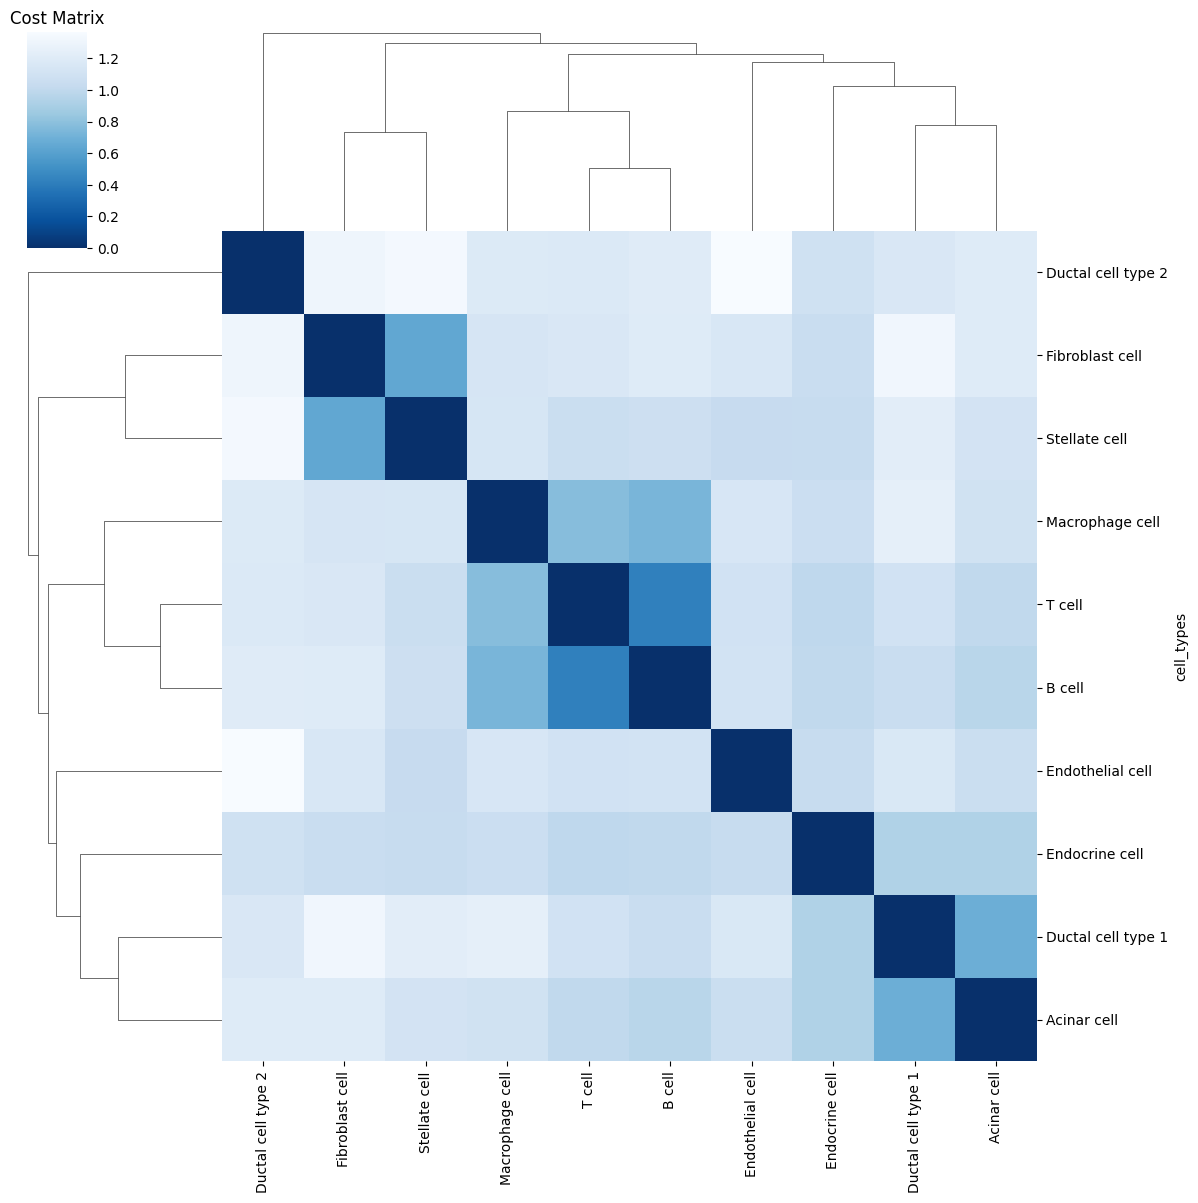

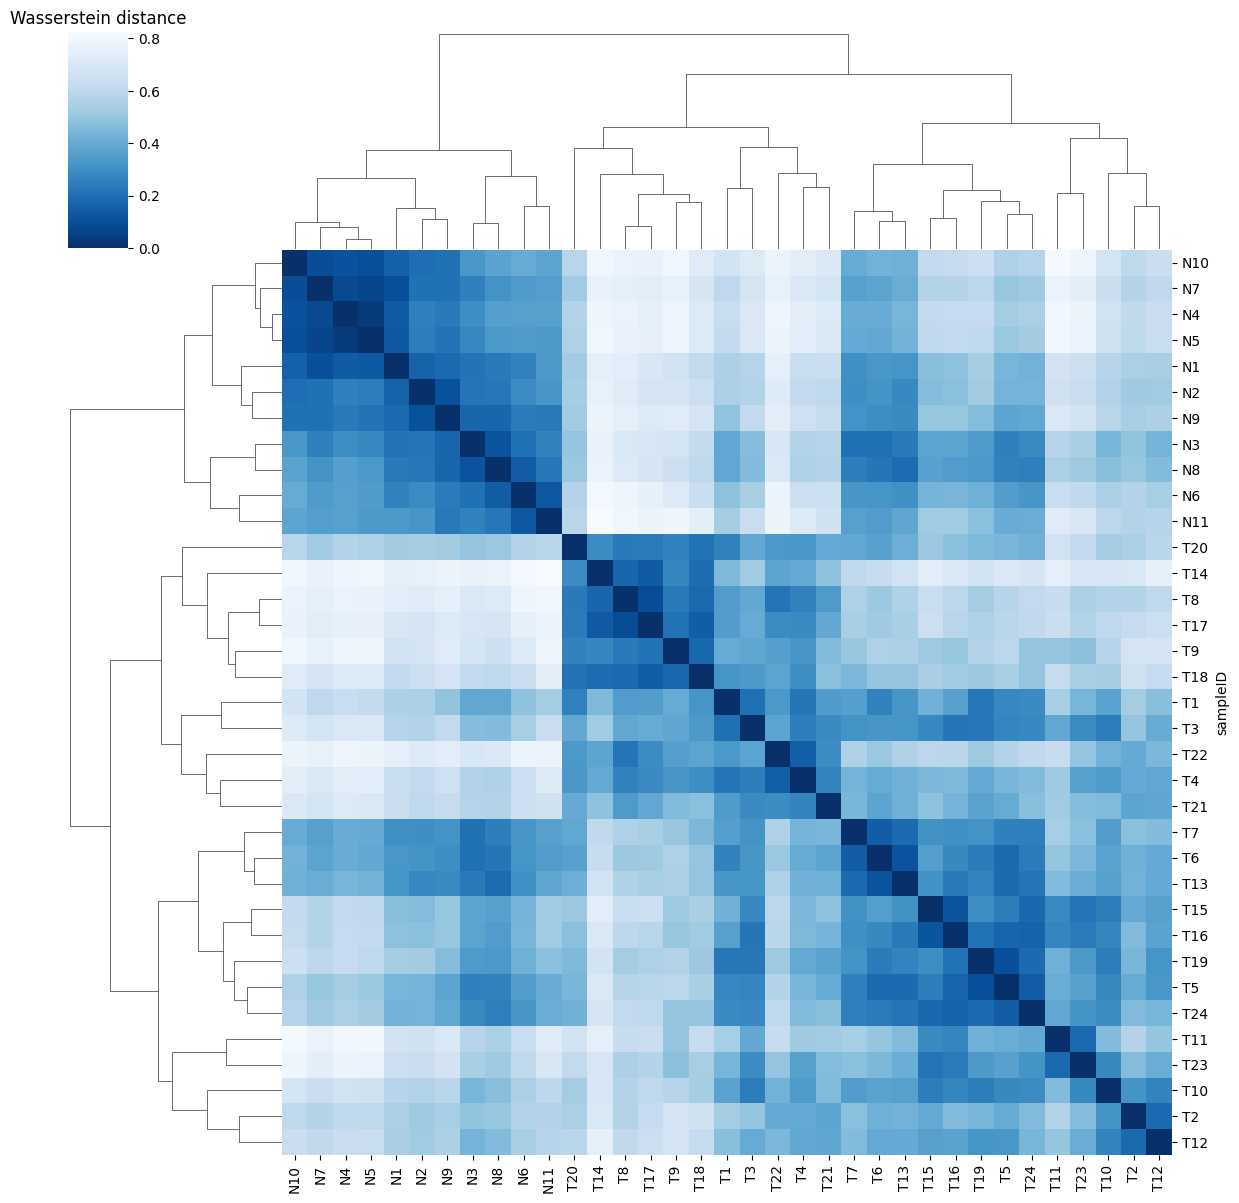

In [4]:
pl.pl.heatmaps(adata)

##### Trajectory:
<div class="alert alert-block alert-info"> 
 Here we show the Diffusion map of Wasserstein distance. In the upcoming trajectory analysis, the labels "T" stands for Tumor and "N" stands for the Normal.
</div>

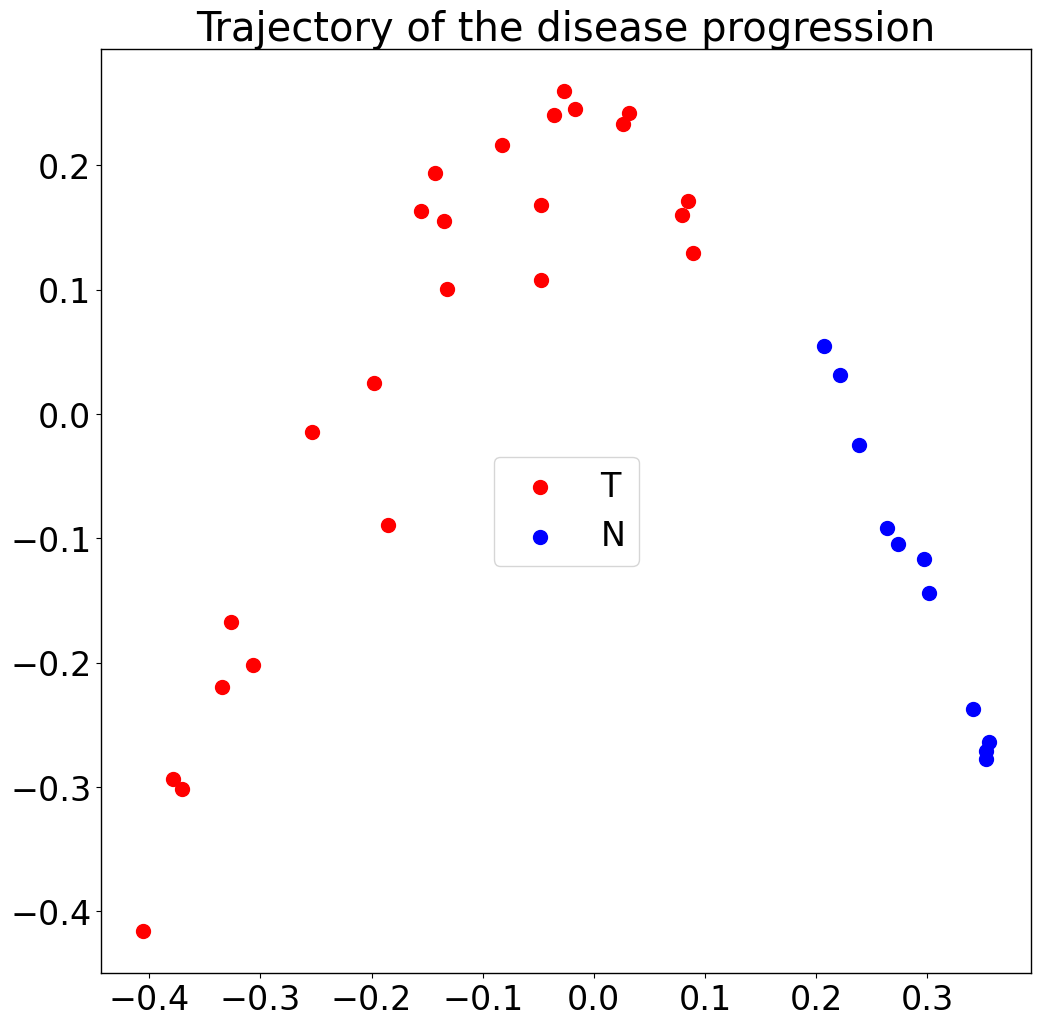

In [5]:
pl.pl.trajectory(adata, colors = ['red','Blue'])

##### In this section, we should find the optimal number of clusters. 
<div class="alert alert-block alert-info"> 
The Silhouette Score Curve is used to find the optimal number of clusters by plotting the average Silhouette Score for different numbers of clusters. The number of clusters corresponding to the highest average Silhouette Score is considered the optimal number of clusters.
</div>


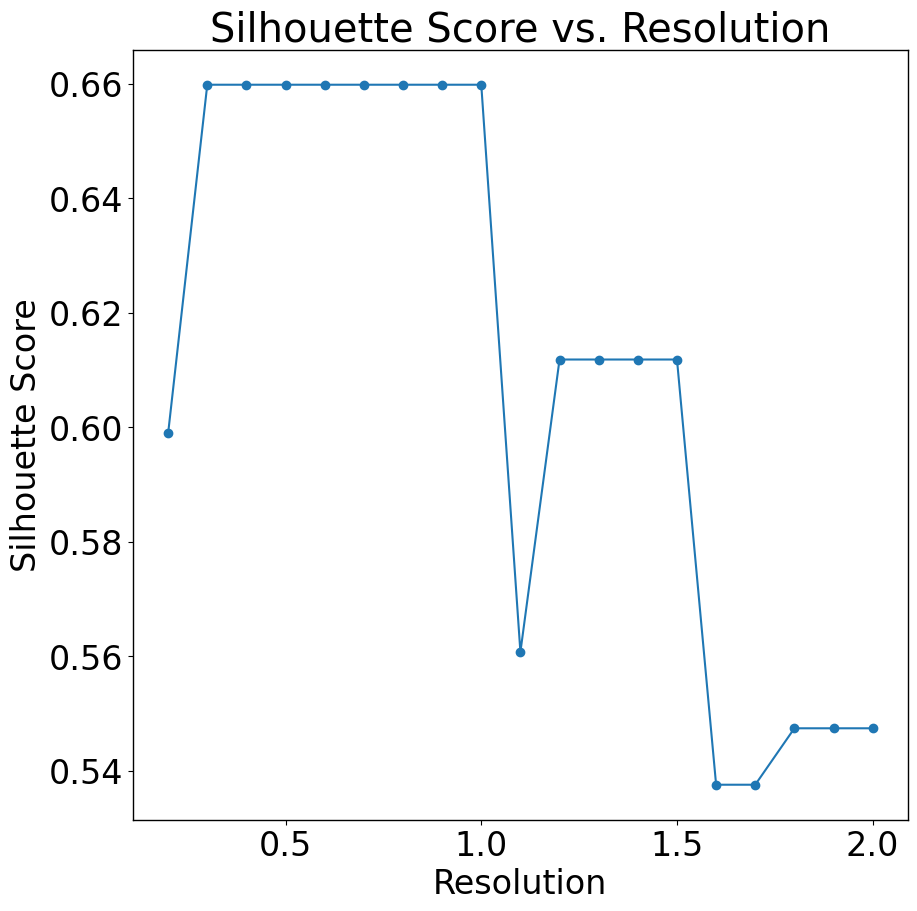

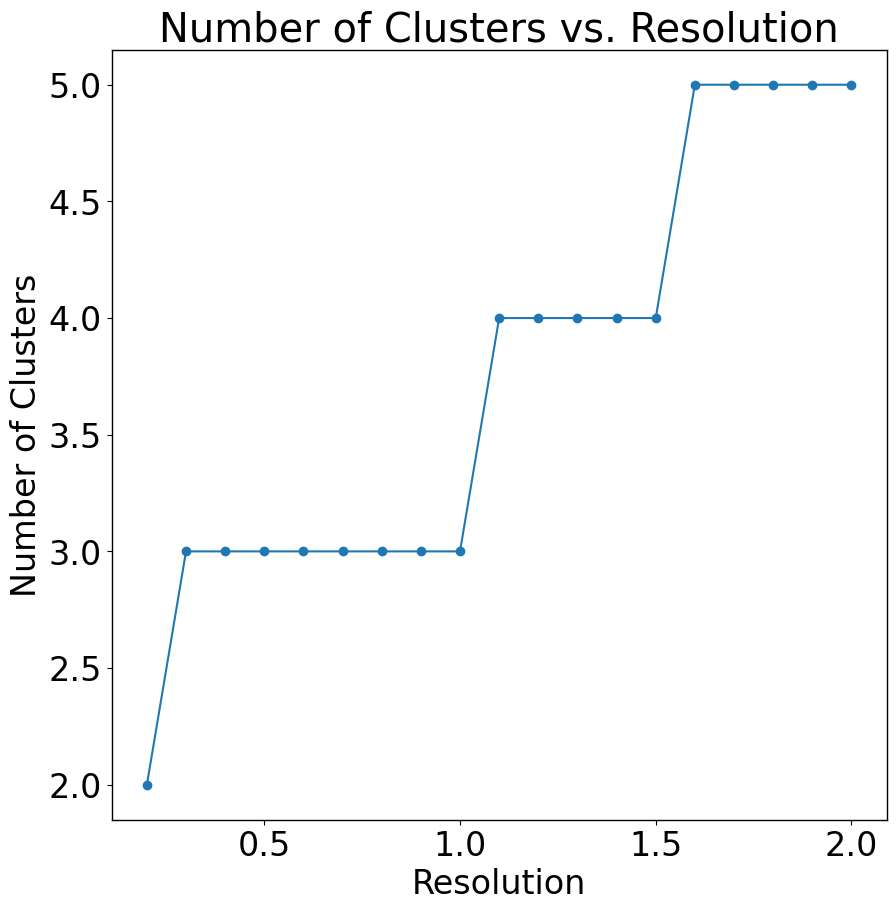

In [6]:
pl.pl.select_best_sil(adata)

##### Patients sub-group detection by clustering EMD. 
<div class="alert alert-block alert-info"> 
Using the Silhouette scores of the previous step, we can find the optimal number of cluster of patients to detect different stage of disease. 
</div>

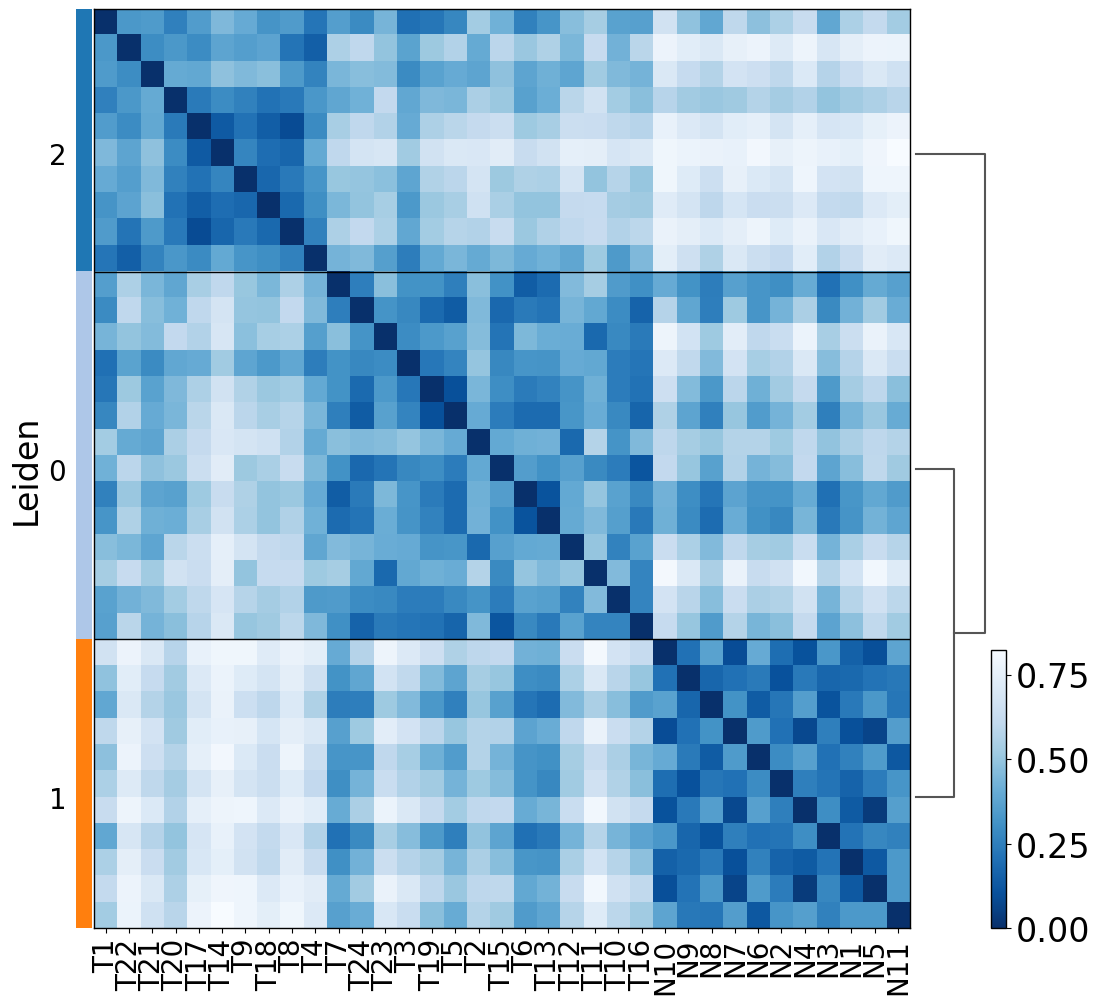

In [7]:
proportion_df=pl.pl.clustering_emd(adata, res = adata.uns['best_res'])

<div class="alert alert-block alert-info"> 
Here we can see that all of the Normal samples are in cluster 1, so we can rename the name of clusters for future analysis. Although this step is optional, we chose to do it in this tutorial.
 </div>

In [8]:
proportion_df.loc[proportion_df['Predicted_Labels'] == '0', 'Predicted_Labels'] = 'Tumor 1'
proportion_df.loc[proportion_df['Predicted_Labels'] == '1', 'Predicted_Labels'] = 'Normal'
proportion_df.loc[proportion_df['Predicted_Labels'] == '2', 'Predicted_Labels'] = 'Tumor 2'

##### Cell-type selection. 
<div class="alert alert-block alert-info"> 
Importantly, we determine which cell type derives the disease from the first stage to the second stage by detecting cell types have statistically significant changes between two sub-groups. This is done using Welch’s t-test, which is appropriate for unequal variances in two groups of samples.

Based on the adjusted p-value threshold you consider, you can choose how statistically significant the cell types you want to have.
  
</div>

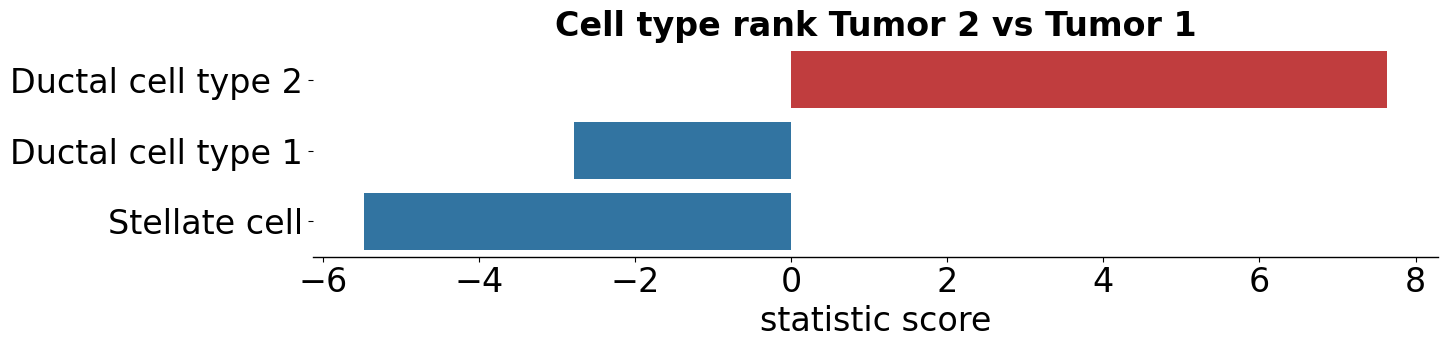

In [9]:
pl.pl.cell_type_diff_two_sub_patient_groups(
    proportion_df,
    proportion_df.columns[0:-2],
    group1 = 'Tumor 2', 
    group2 = 'Tumor 1',
    pval_thr = 0.05, 
    figsize = (15, 4)
    )

<div class="alert alert-block alert-info"> 
Next, we can check the distribution of each patient sub-group in each cell type (the three above ones).
</div>

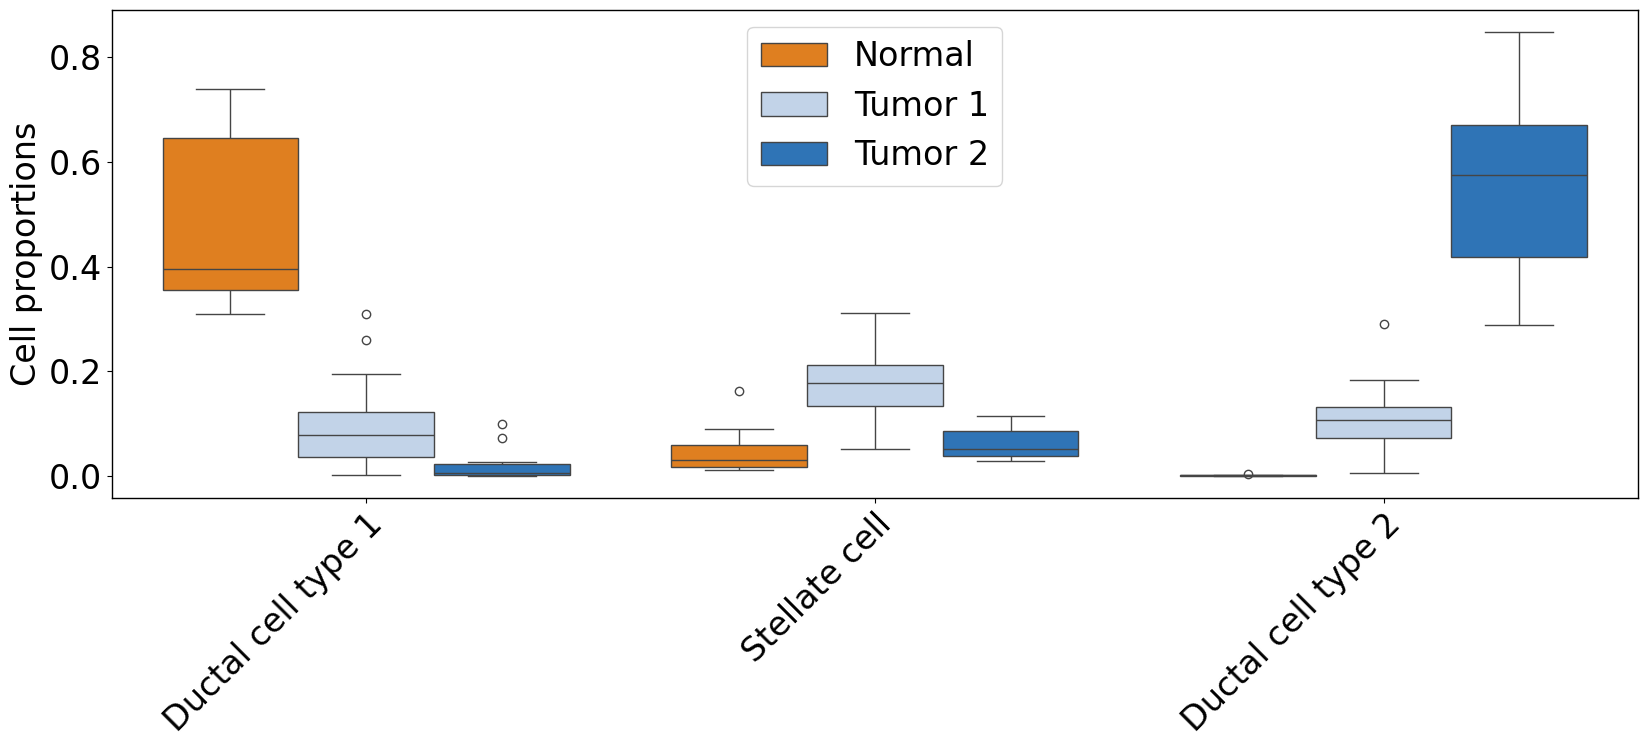

In [10]:
pl.pl.plot_cell_types_distributions(
    proportion_df,
    cell_types = ['Stellate cell','Ductal cell type 2','Ductal cell type 1'],
    figsize = (17,8),
    label_order = ['Normal', 'Tumor 1', 'Tumor 2'],
    label_colors = ['#FF7F00','#BCD2EE','#1874CD']
    )

<div class="alert alert-block alert-info"> 
 We also can check the distribution of each patient sub-group in the whole cell types.
</div>

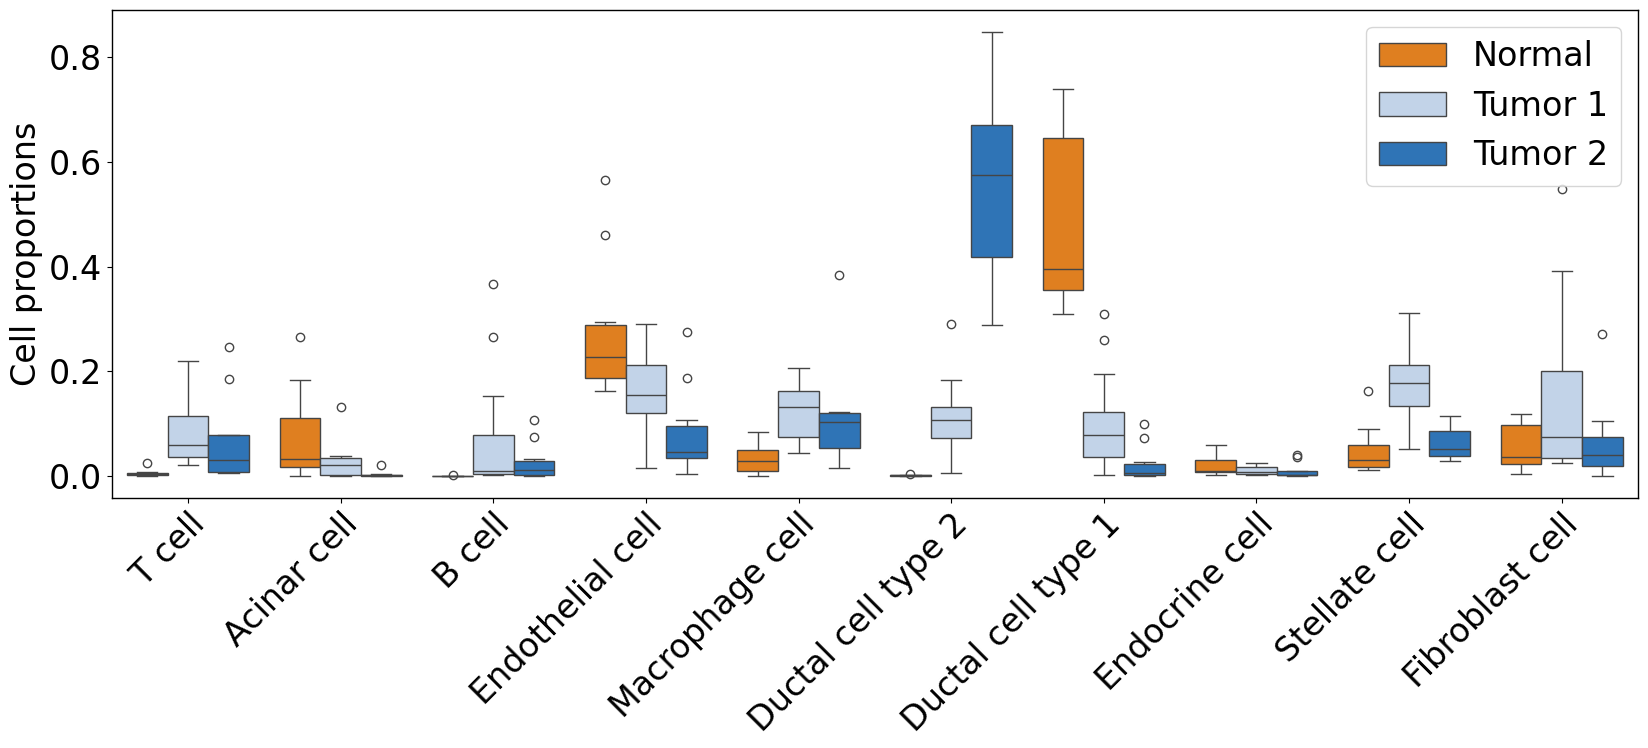

In [11]:
pl.pl.plot_cell_types_distributions(
    proportion_df,
    cell_types = list(proportion_df.columns[0:-2]),
    figsize = (17,8),
    label_order = ['Normal', 'Tumor 1', 'Tumor 2'],
    label_colors = ['#FF7F00','#BCD2EE','#1874CD']
    )

<div class="alert alert-block alert-info"> 
In the statistical table generated in your results path, all cell types are sorted based on the score and their adjusted p-value.
cell types with positive scores shows the most differences cell types in group 1 compared with group 2 and negative scores shows the other way. 
You can the results in 'Results_PILOT/Diff_Expressions_Results' folder.
</div>

#### Differential expression analysis
<div class="alert alert-block alert-info"> 
At this point for each cell type the plots and results are saved at 'Results_PILOT/Diff_Expressions_Results' folder.
</div>

##### Note:

<div class="alert alert-block alert-info"> 
This step needs the 'limma' package in R, You need to run this function to install it (if you have not already done)!
</div>

In [12]:
# pl.tl.install_r_packages()

##### Ductal cell type 1

<div class="alert alert-block alert-info"> 
In the next step, for specific cell types, we find the Differential genes between two interested patient sub-groups
Based on the fold change threshold, you can determine how much difference you want to see between two interested patients sub-groups. For the tutorial, we already saved the needed input for this function (2000 highly variable genes for each cell type). 
    
- You can run this function for your own data, and it automatically extracts the gene expressions for each cell type ("2000 highly variable genes). In case you want all/more genes, please change the "highly_variable_genes_" or "n_top_genes" parameters.
</div>

run limma lmFit
run limma eBayes


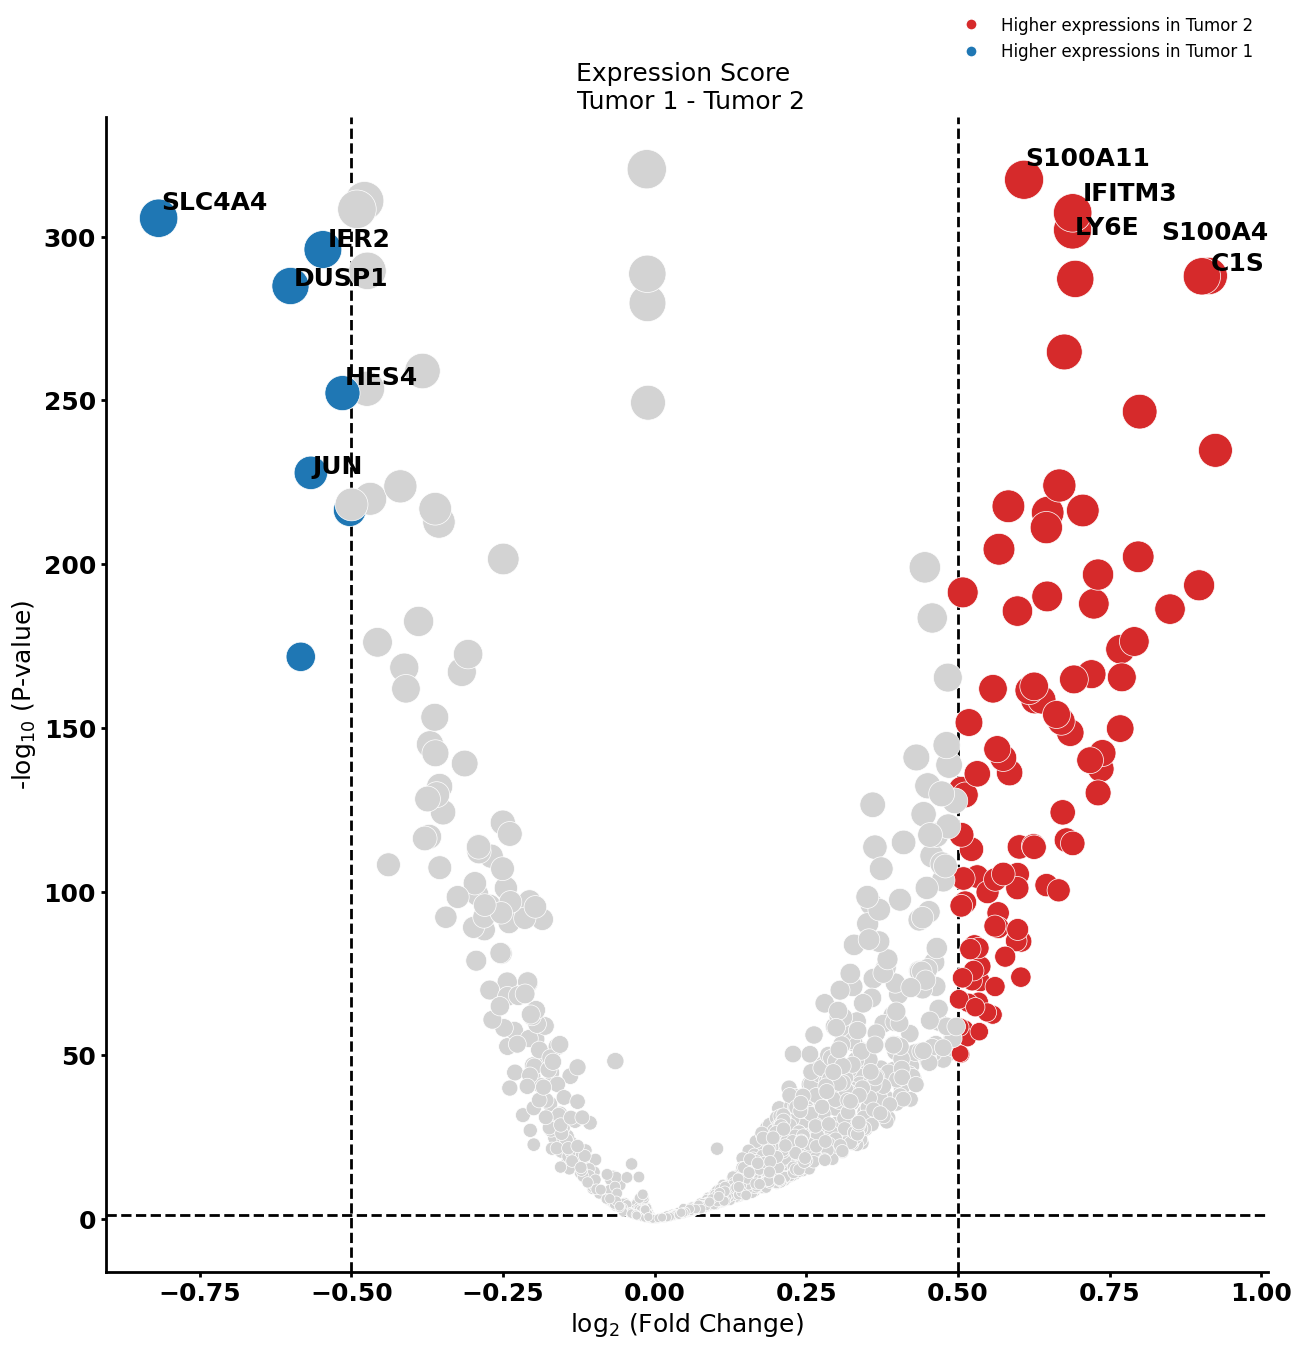

In [14]:
cell_type = "Ductal cell type 1" #look at the Cells folder
pl.tl.compute_diff_expressions(
    adata,
    cell_type,
    proportion_df,
    fc_thr =  0.5,
    pval_thr = 0.05,
    group1 = 'Tumor 1', 
    group2 = 'Tumor 2',
    sample_col = 'sampleID',
    col_cell = 'cell_types',
    )

###### Gene Ontology analysis

<div class="alert alert-block alert-info">  Based on the adjusted p-value and fold change threshold, we select genes that are highly differentiated in each patient sub-groups and specify their annotation using the <a href="https://biit.cs.ut.ee/gprofiler/gost">gProfiler</a>
    
</div>

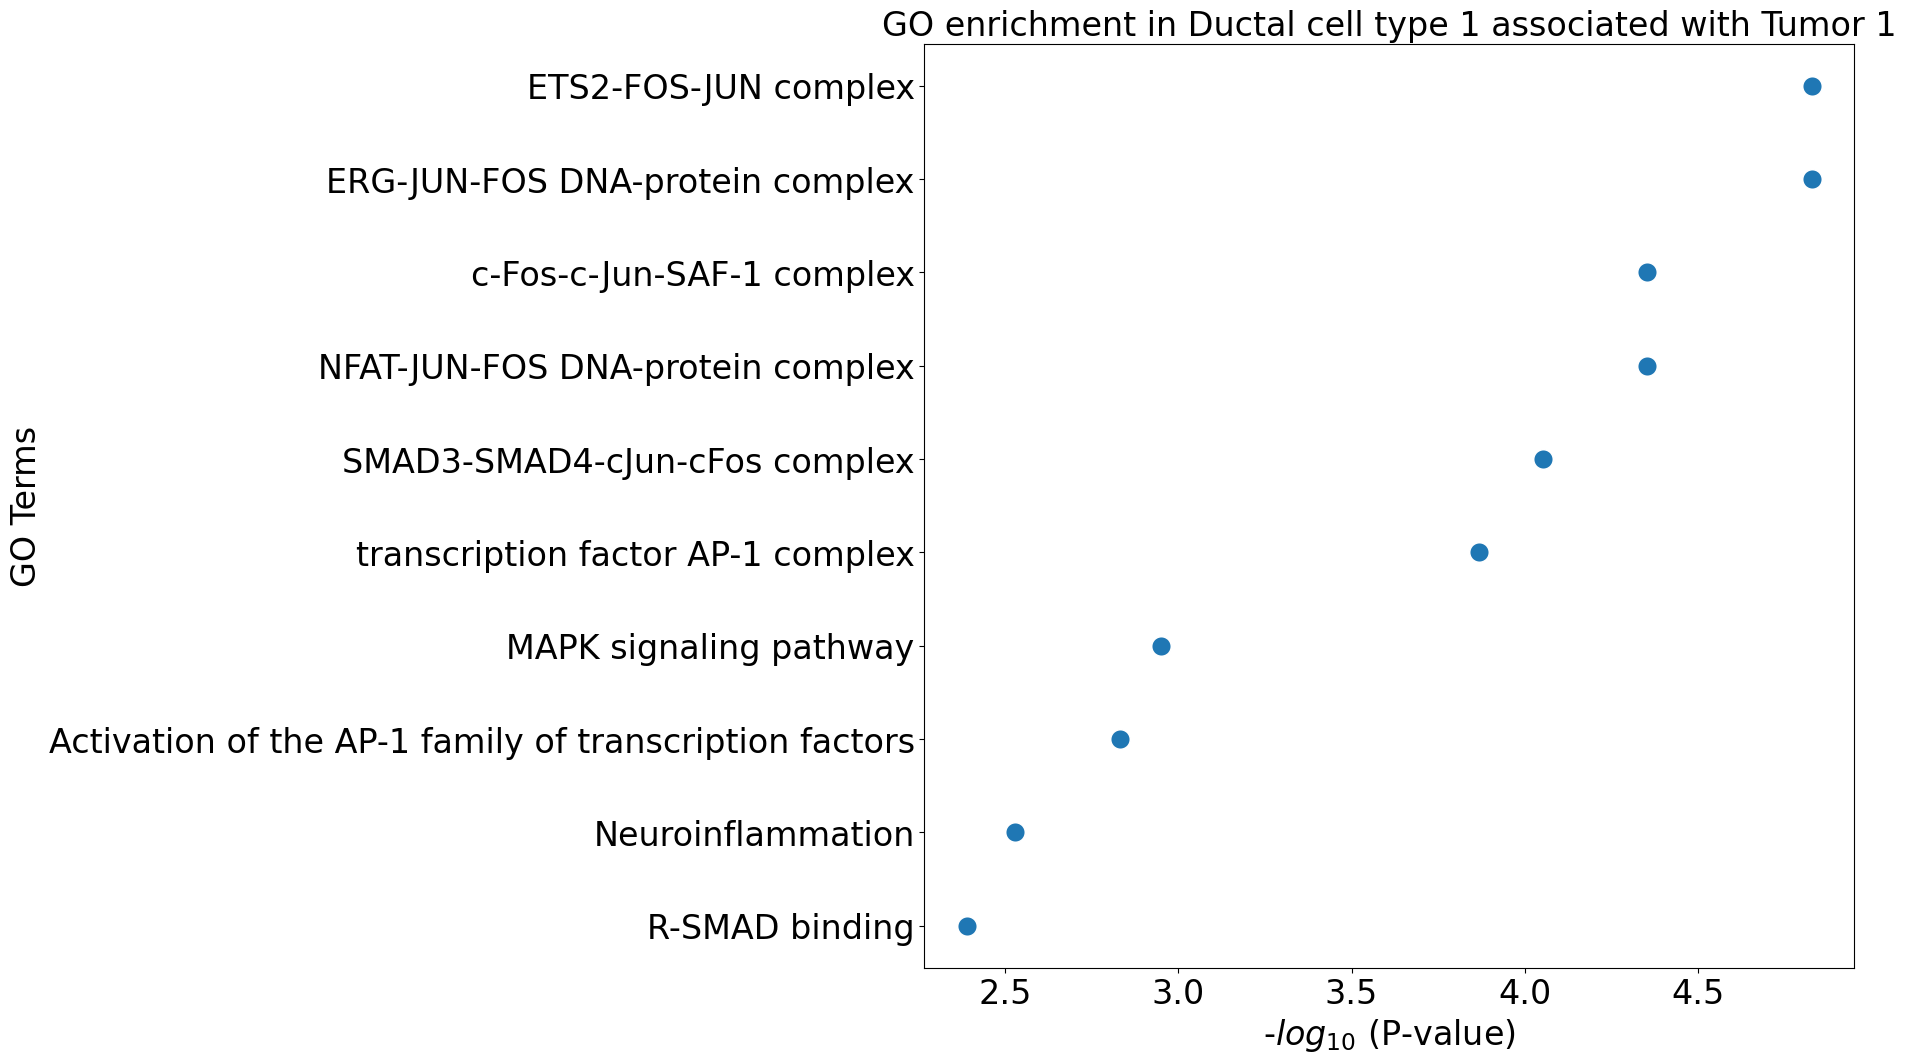

In [14]:
pl.pl.gene_annotation_cell_type_subgroup(
    cell_type = cell_type, 
    group = 'Tumor 1',
    num_gos = 10
    )

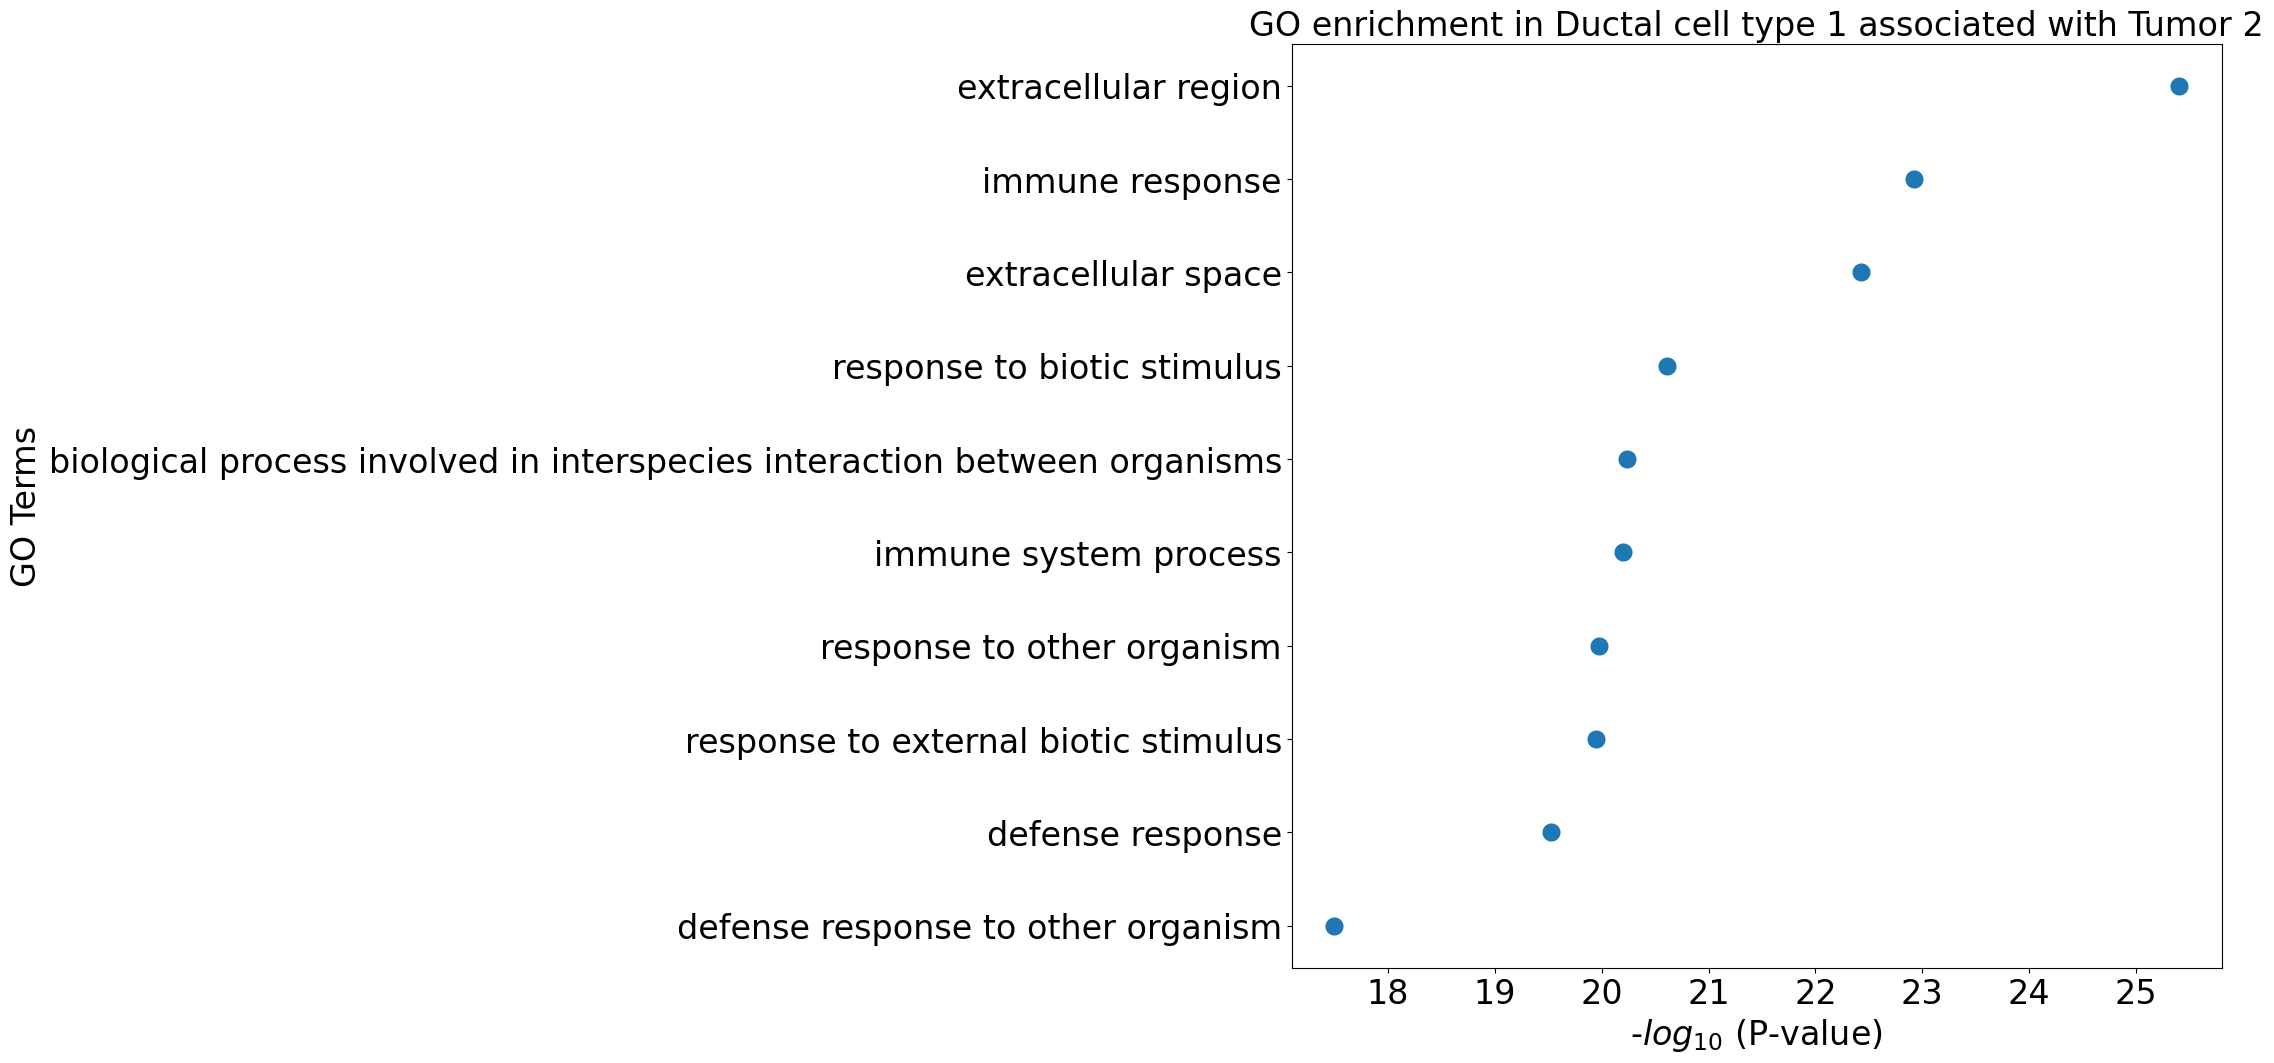

In [15]:
pl.pl.gene_annotation_cell_type_subgroup(
    cell_type = cell_type,
    group = 'Tumor 2',
    num_gos = 10
    )

##### Stellate cell

run limma lmFit
run limma eBayes


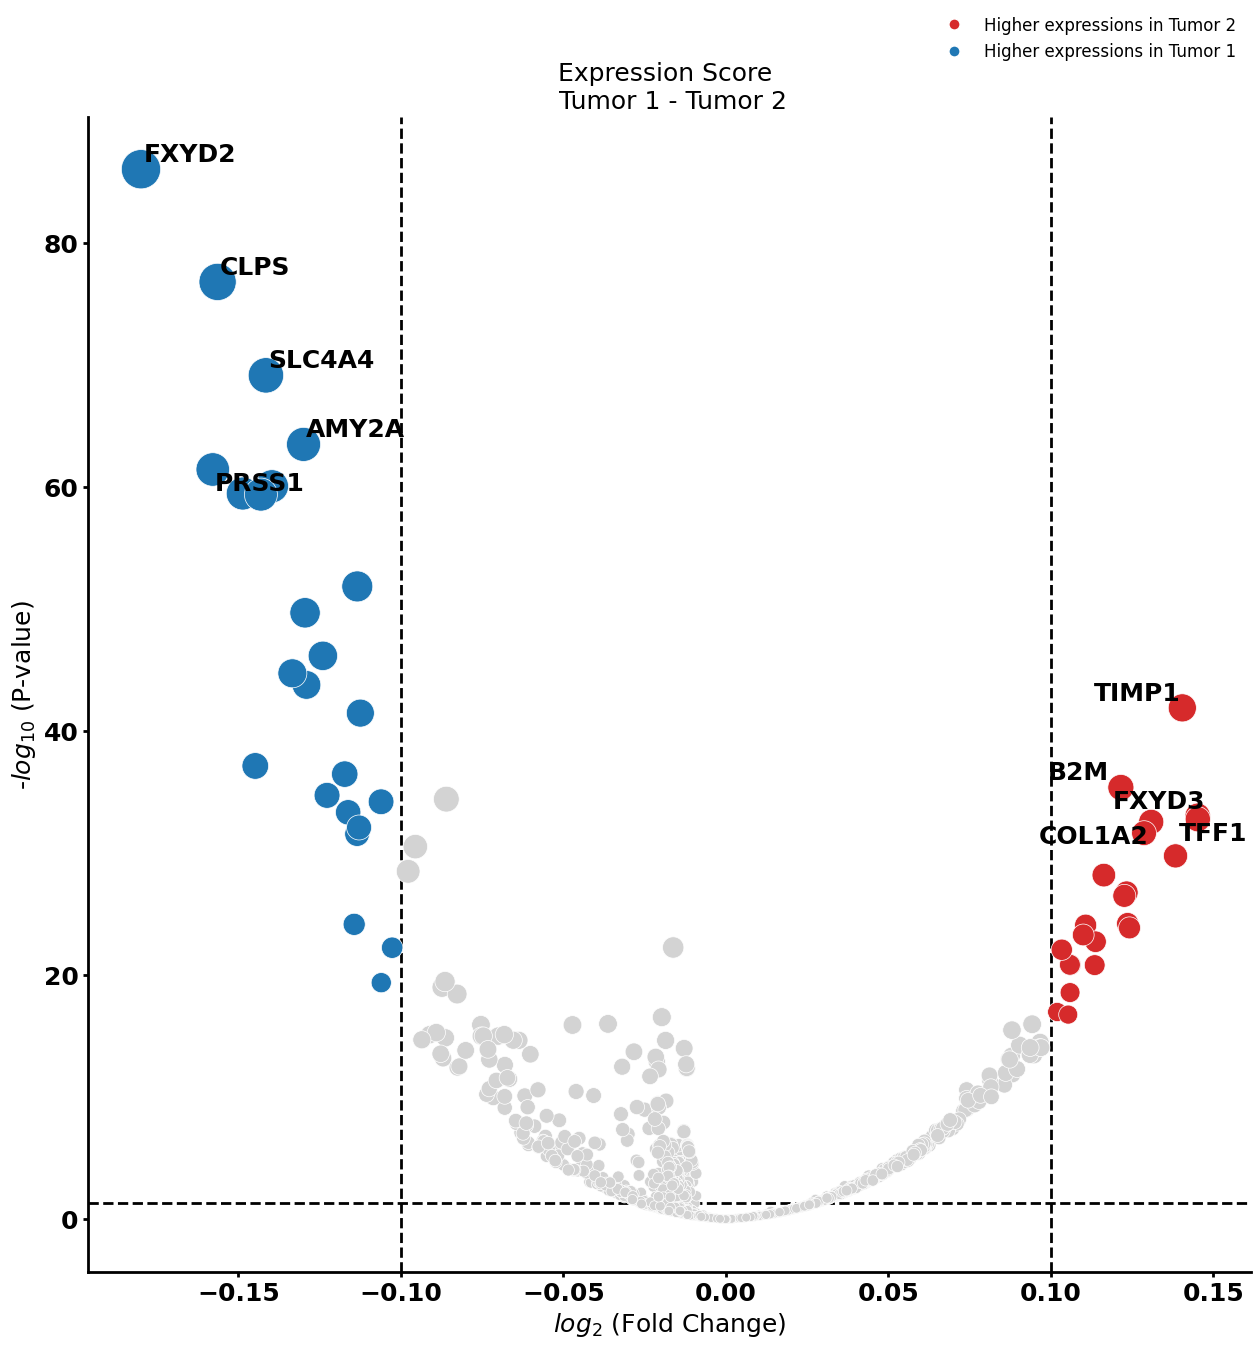

In [16]:
cell_type = "Stellate cell" 
pl.tl.compute_diff_expressions(
    adata,
    cell_type,
    proportion_df,
    fc_thr = 0.1,
    pval_thr = 0.05,
    group1 = 'Tumor 1',
    group2 = 'Tumor 2',
    sample_col = 'sampleID',
   col_cell = 'cell_types'
    )

###### Gene Ontology analysis

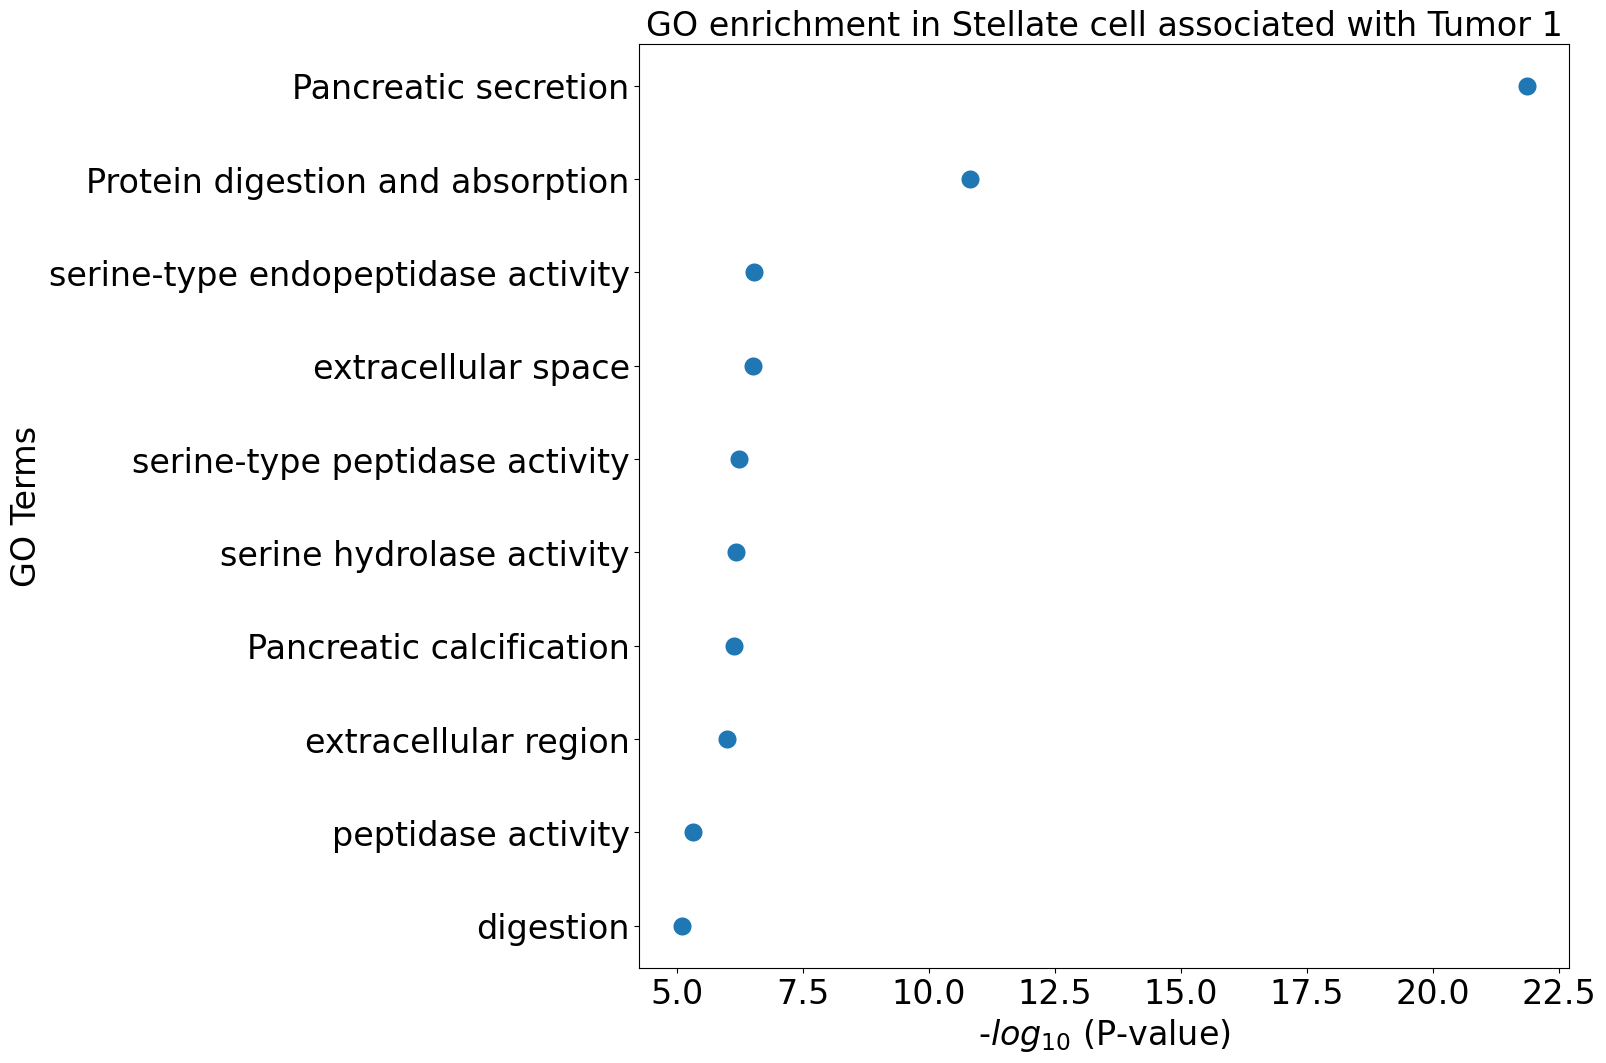

In [17]:
pl.pl.gene_annotation_cell_type_subgroup(
    cell_type = cell_type, 
    group = 'Tumor 1',
    num_gos = 10
    )

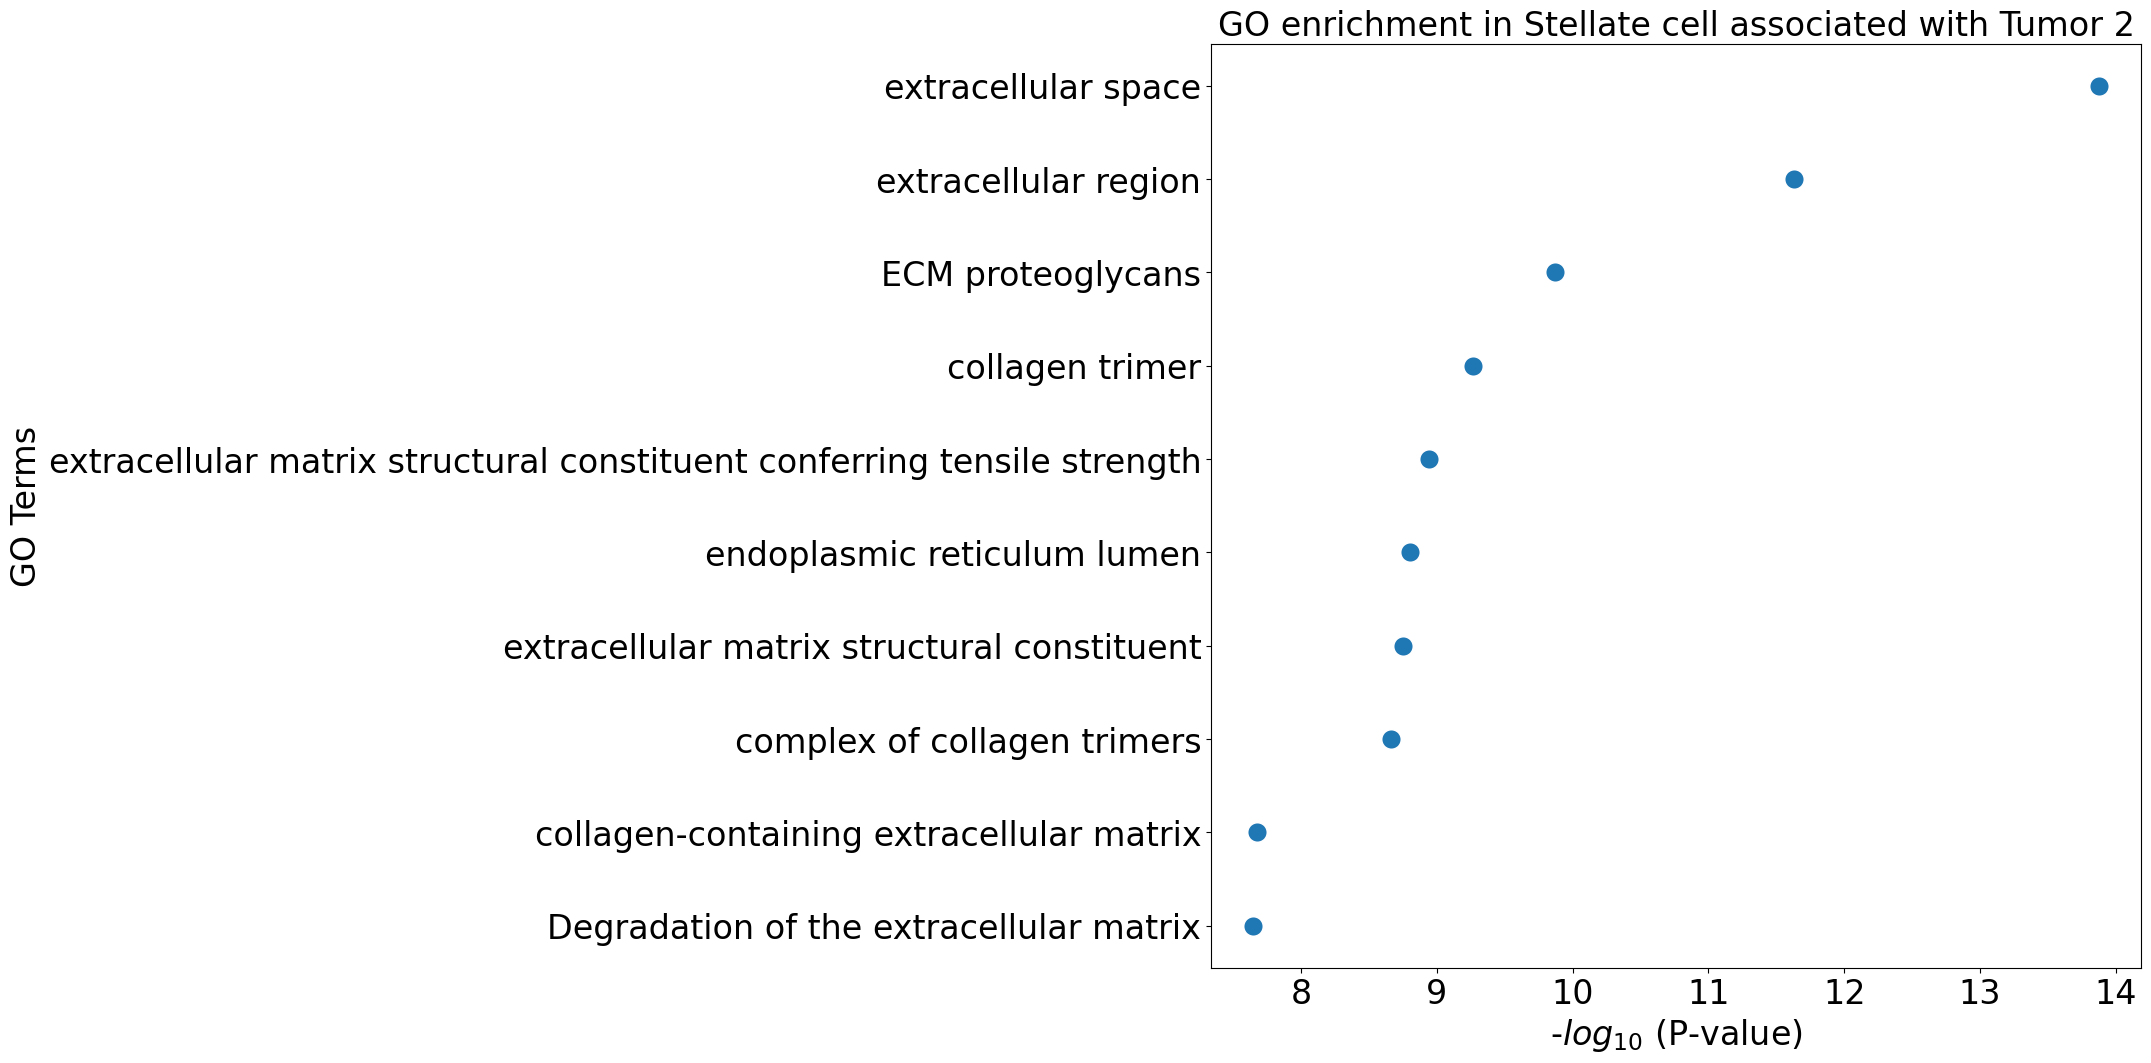

In [18]:
pl.pl.gene_annotation_cell_type_subgroup(
    cell_type = cell_type,
    group = 'Tumor 2',
    num_gos = 10
    )

##### Ductal cell type 2

run limma lmFit
run limma eBayes


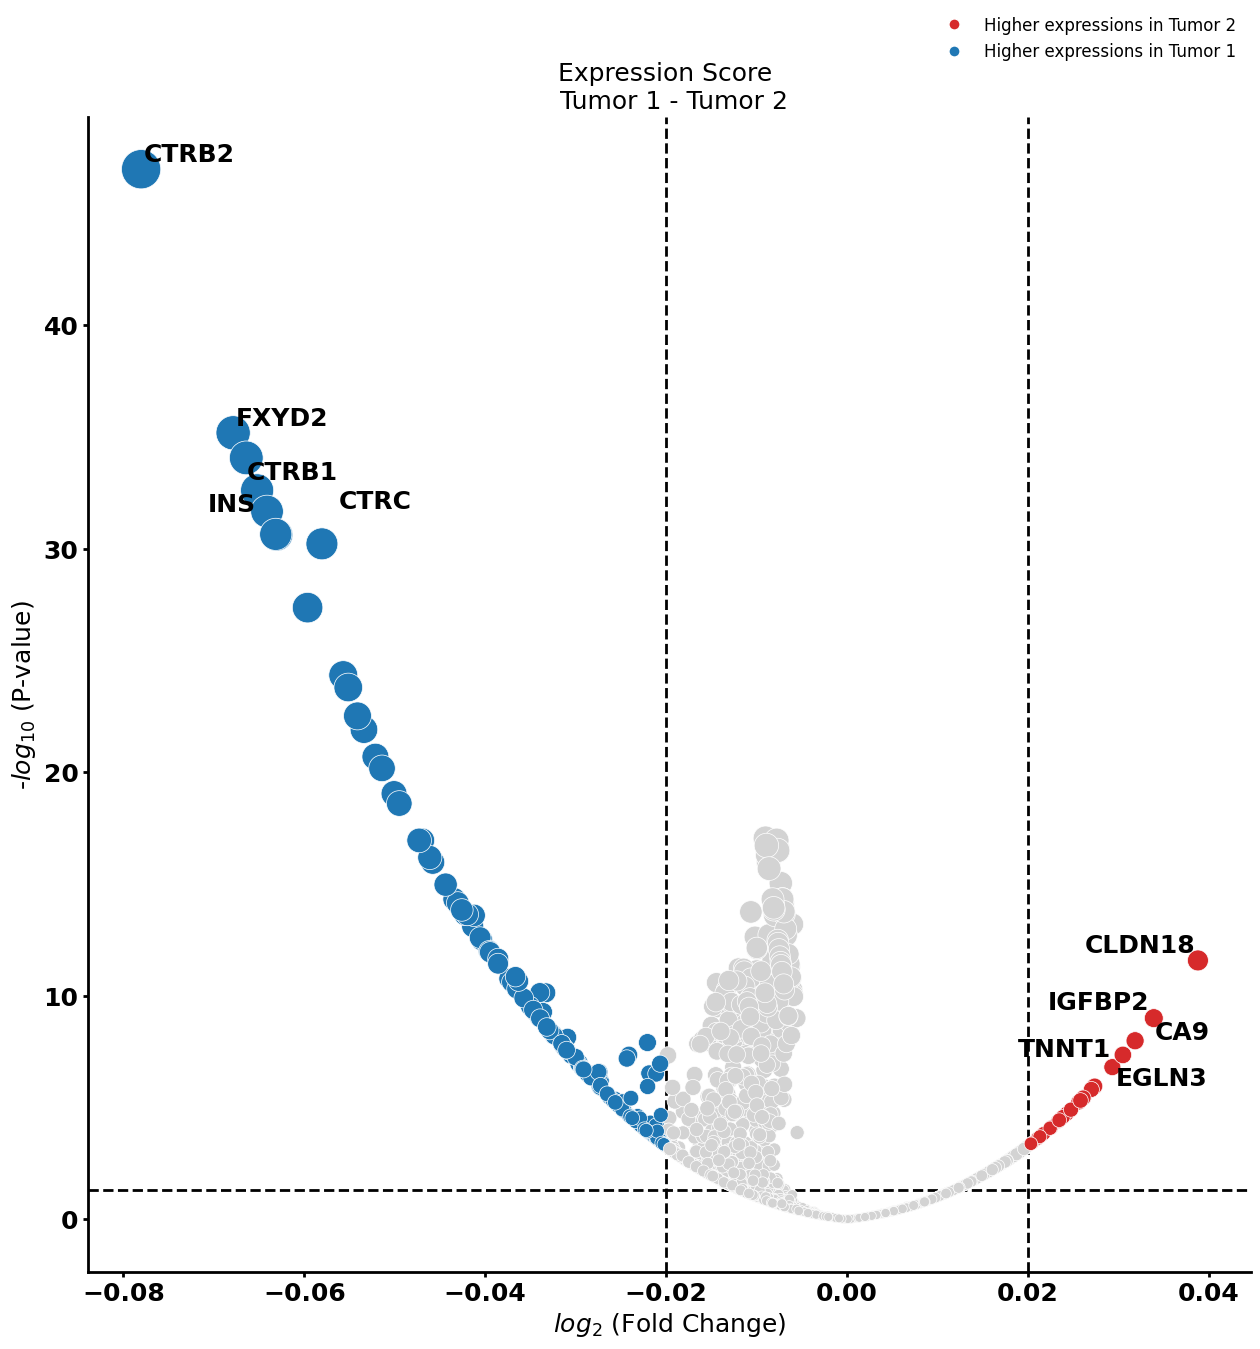

In [19]:
cell_type = "Ductal cell type 2" 
pl.tl.compute_diff_expressions(
    adata,
    cell_type, 
    proportion_df,
    fc_thr = 0.020,
    pval_thr = 0.05,
    group1 = 'Tumor 1',
    group2 = 'Tumor 2',
    sample_col = 'sampleID',
    col_cell = 'cell_types',
    )

###### Gene Ontology analysis

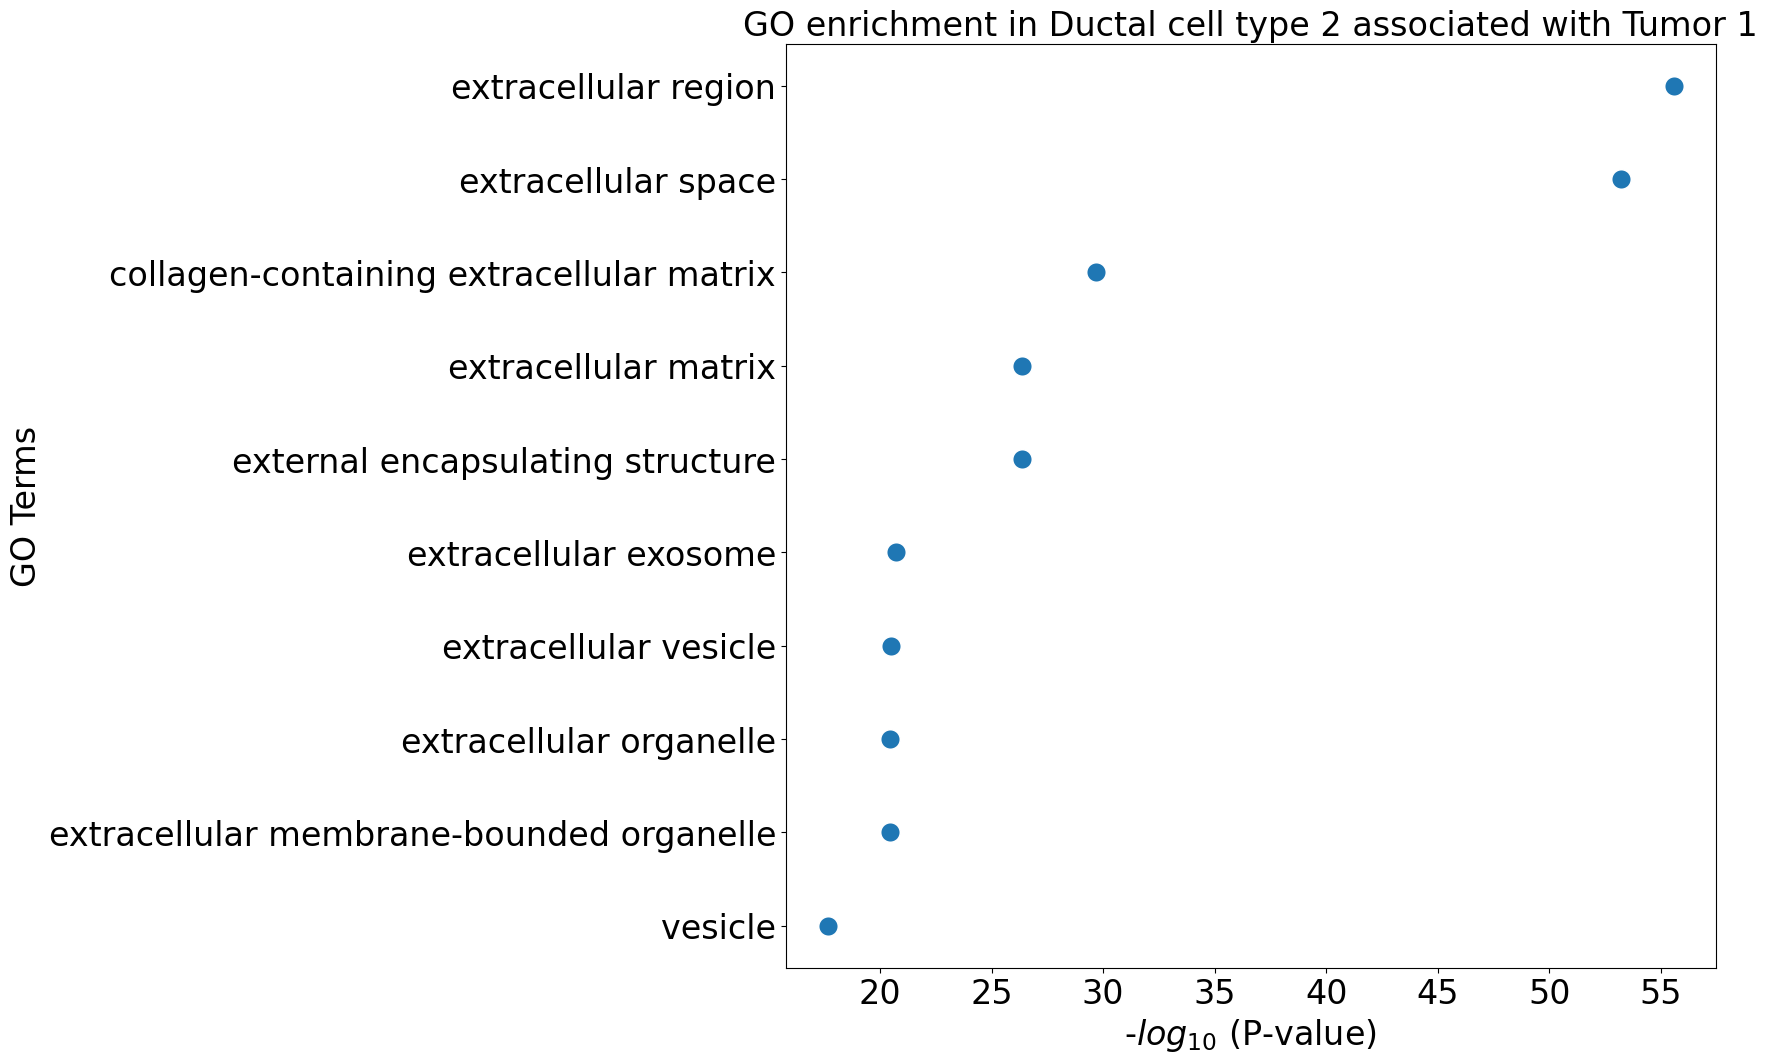

In [20]:
pl.pl.gene_annotation_cell_type_subgroup(
    cell_type = cell_type,
    group = 'Tumor 1',
    num_gos = 10
    )

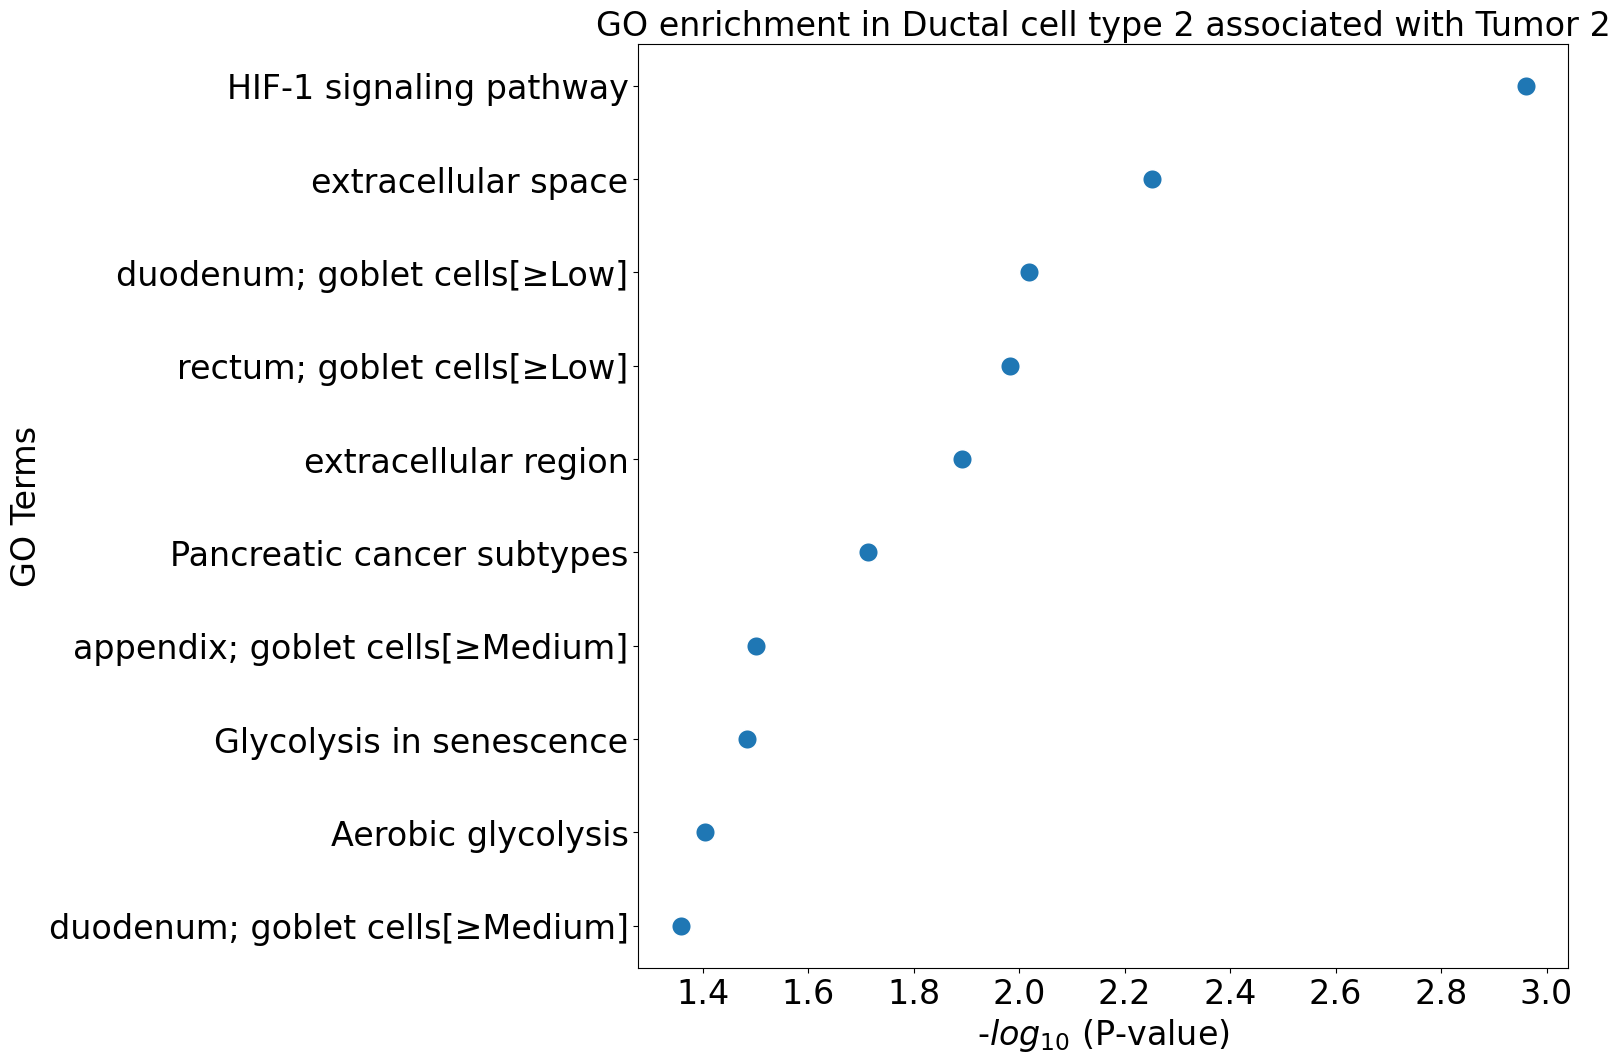

In [21]:
pl.pl.gene_annotation_cell_type_subgroup(
    cell_type = cell_type, 
    group = 'Tumor 2',
    num_gos = 10
    )

#### Pseudobulk differential expression analysis
<div class="alert alert-block alert-info">In some situations, We are interested in the genes are expressed different at the sample level without considering the variation across the cells. We define pseudo-bulk samples as summing counts for all cells with the same combination of label and sample. We use the DESeq2 tool to perform pseudo-bulk differential expression analysis on a specific cell type sub-patient group</a>
</div>

Plot cells frequency for each sample... 


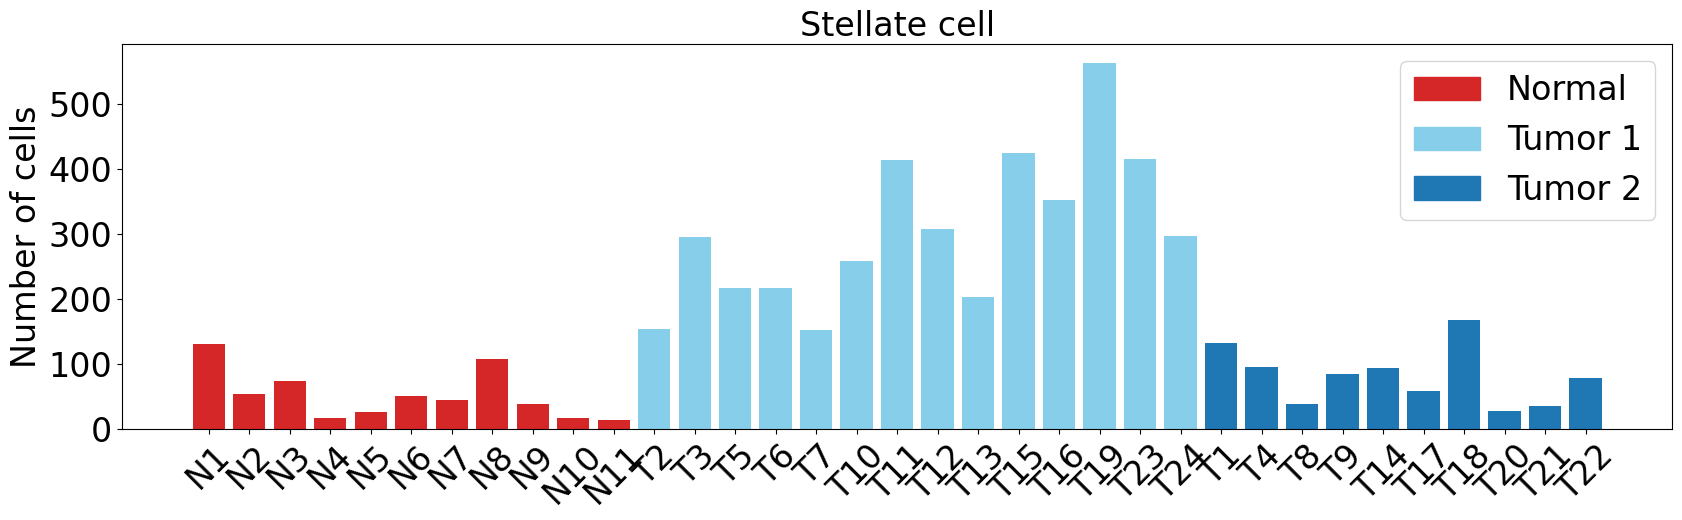

Aggregating the counts and metadata to the sample level...
Use the median of ratios method for count normalization from DESeq2
Use regularized log transform (rlog) of the normalized counts from DESeq2
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()        masks matrixStats::count()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::l

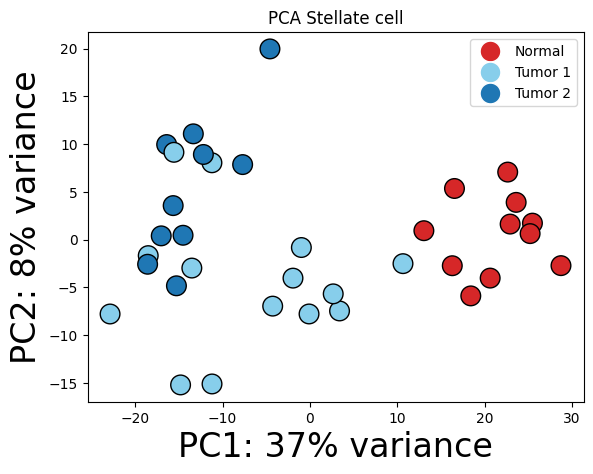

Performing the DE analysis... 
[1] "stage_Tumor.1_vs_Normal"
Plot volcano plot for Tumor 1 vs Normal


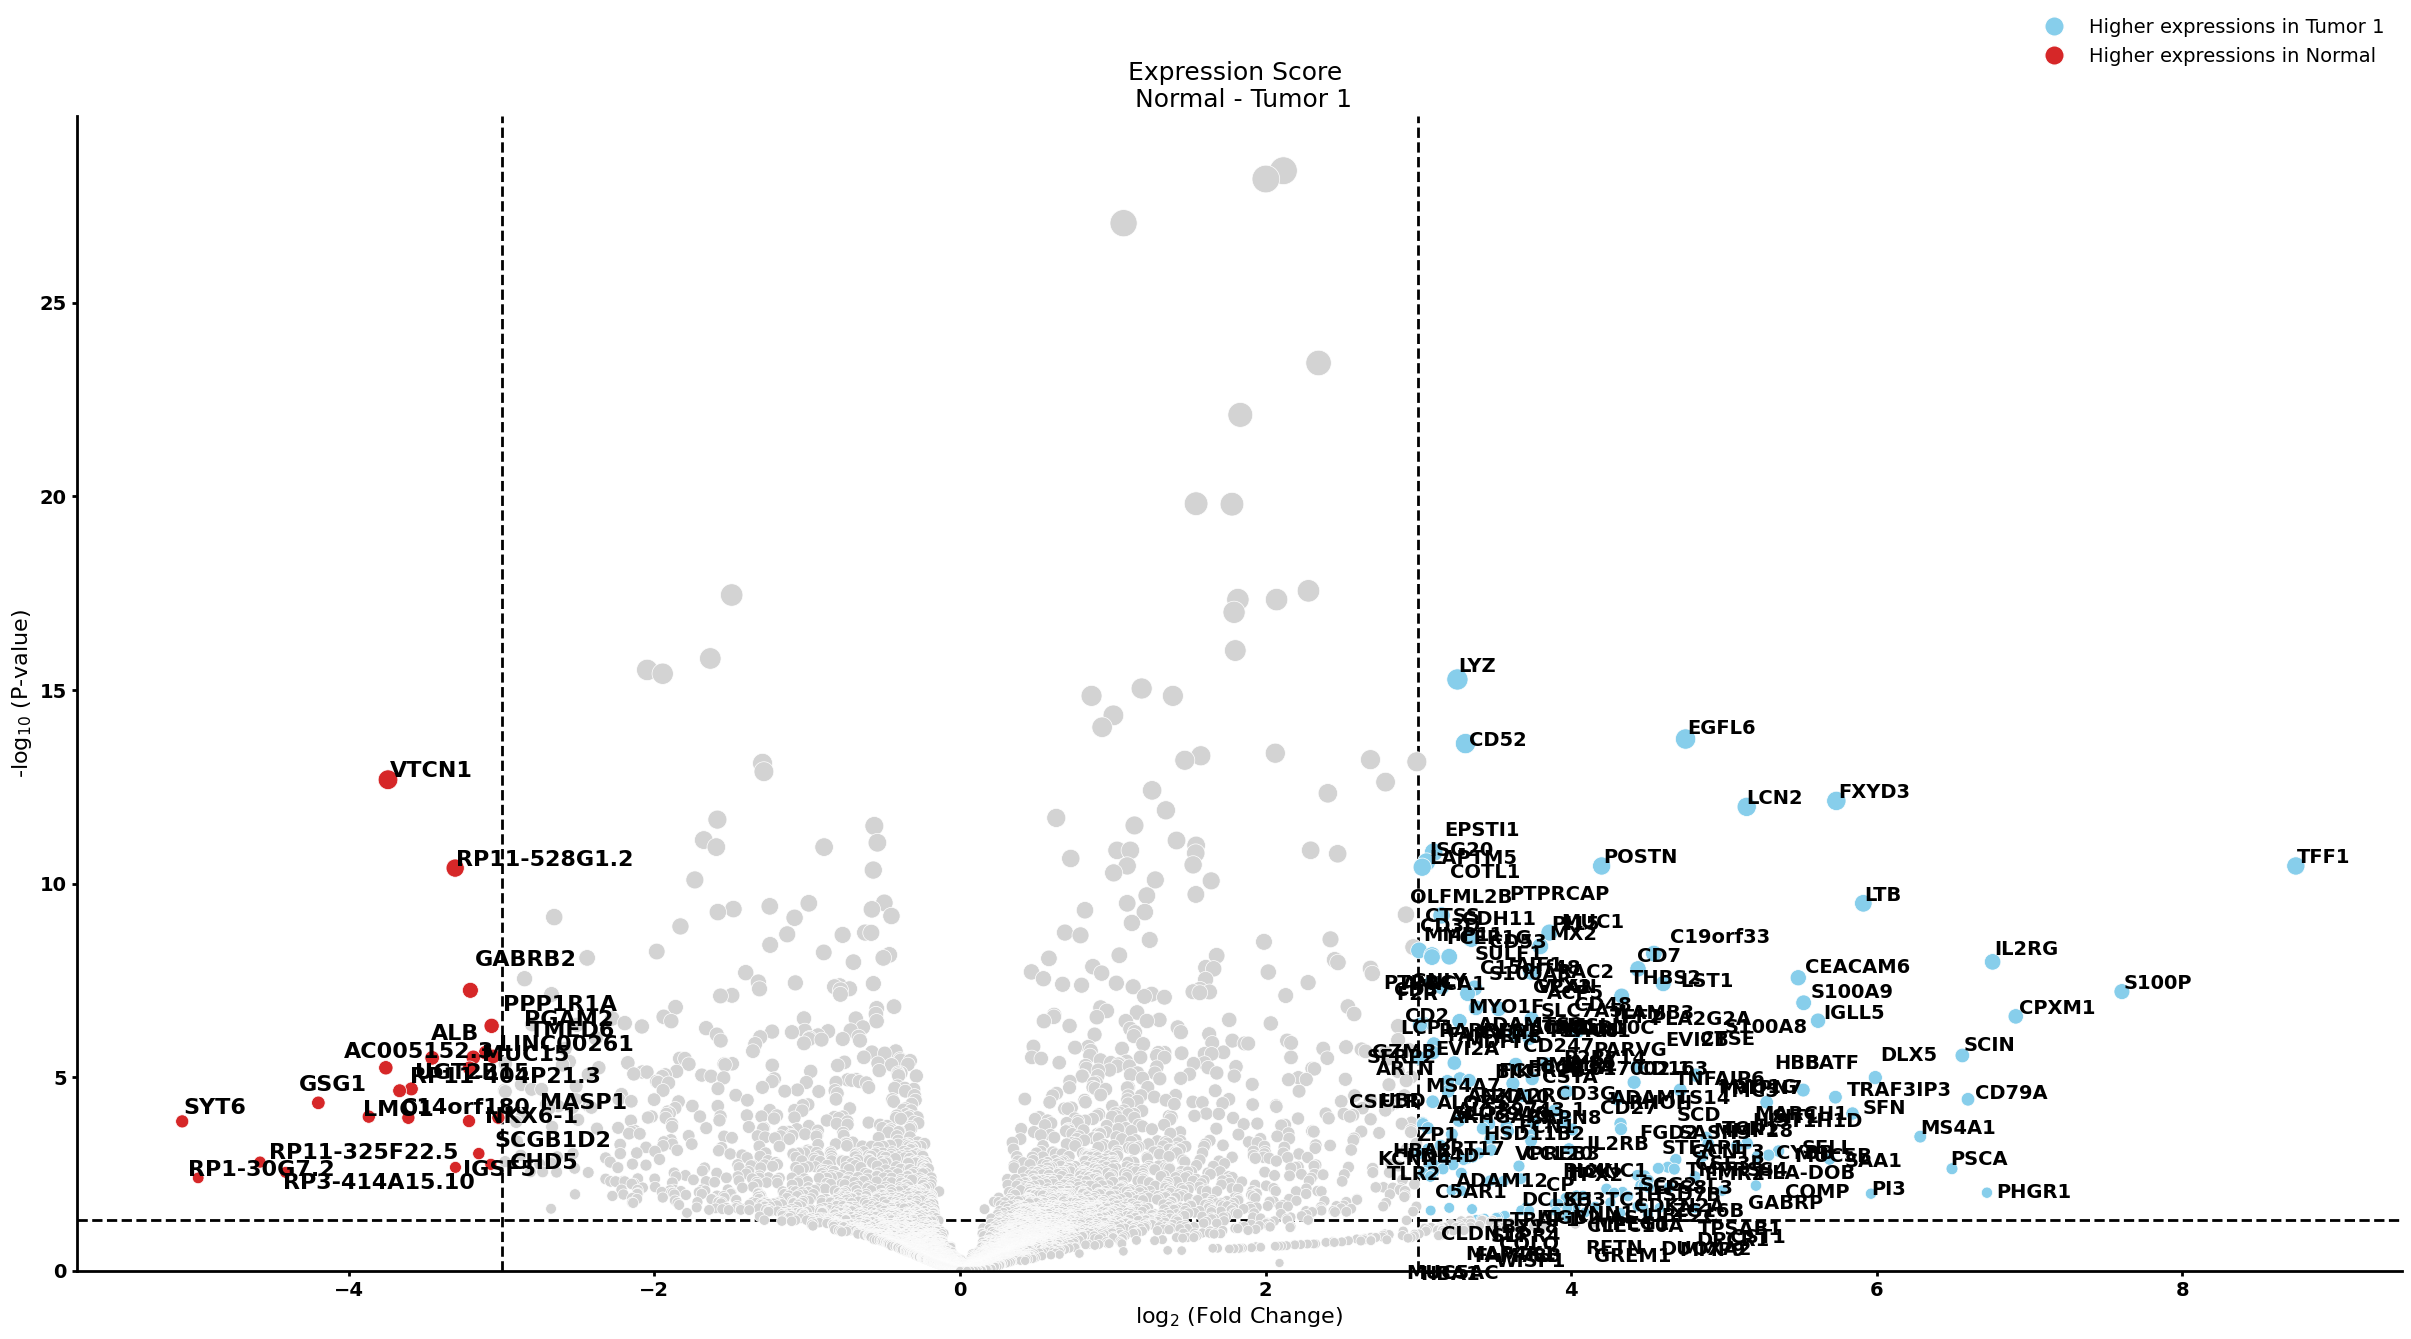

Plot GO analysis for Tumor 1 vs Normal


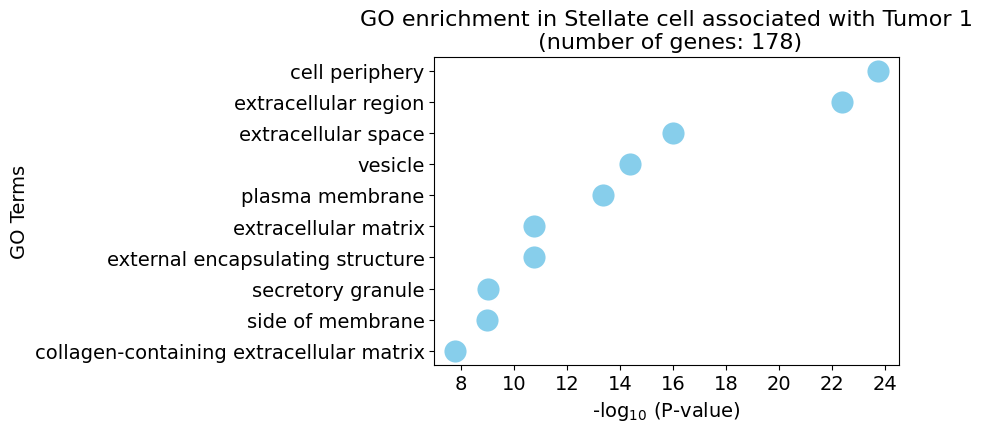

[1] "stage_Tumor.2_vs_Normal"
Plot volcano plot for Tumor 2 vs Normal


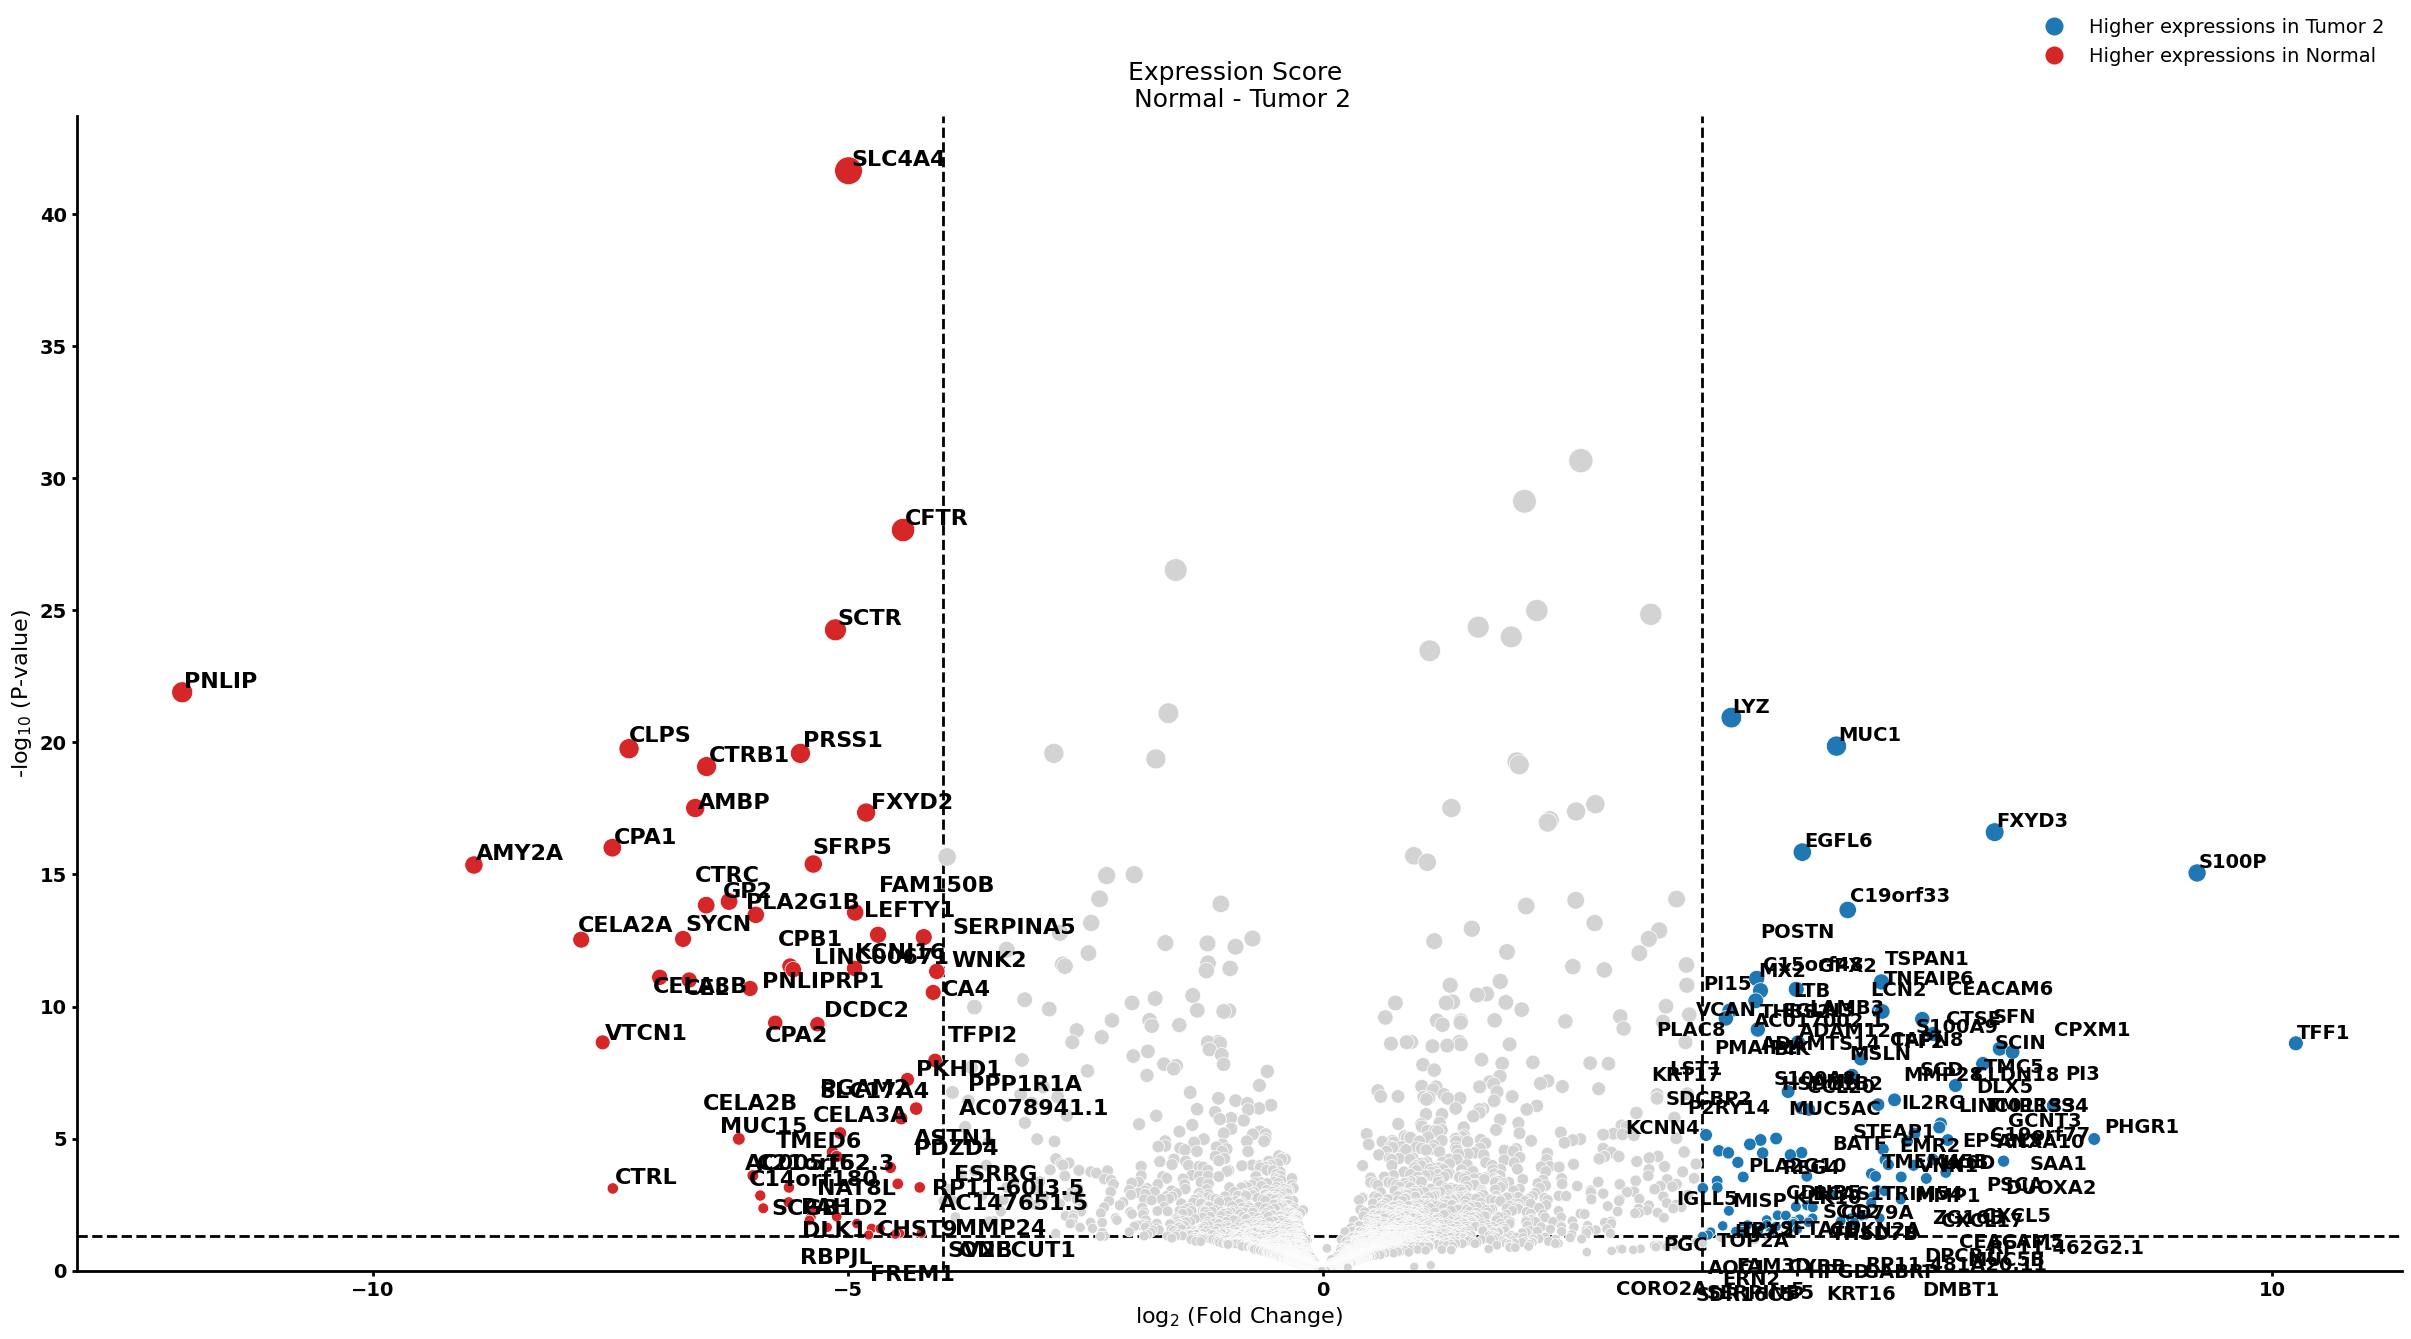

Plot GO analysis for Tumor 2 vs Normal


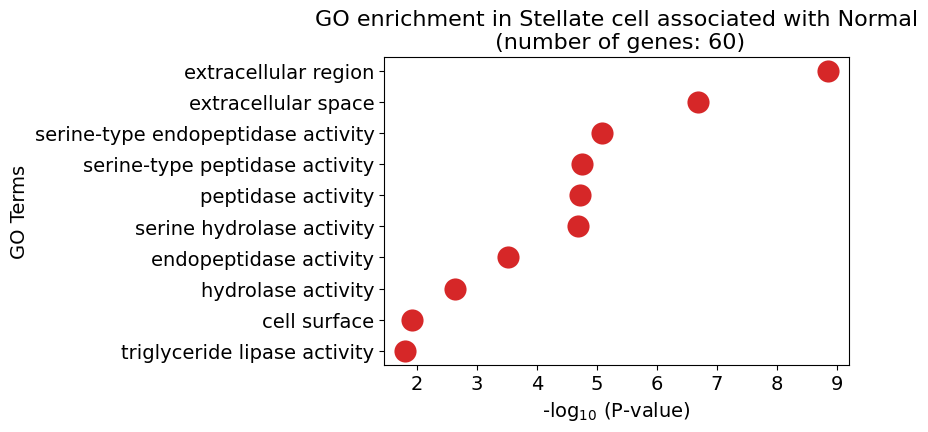

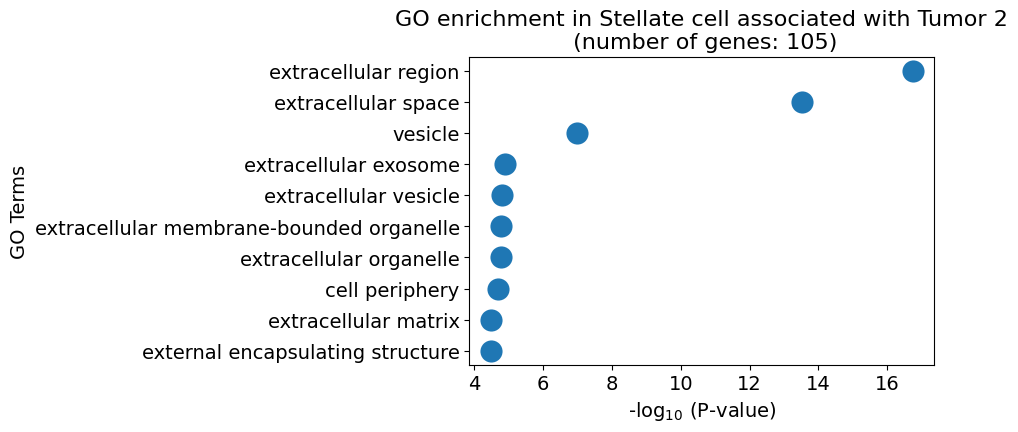

[1] "stage_Tumor.2_vs_Tumor.1"
Plot volcano plot for Tumor 2 vs Tumor 1


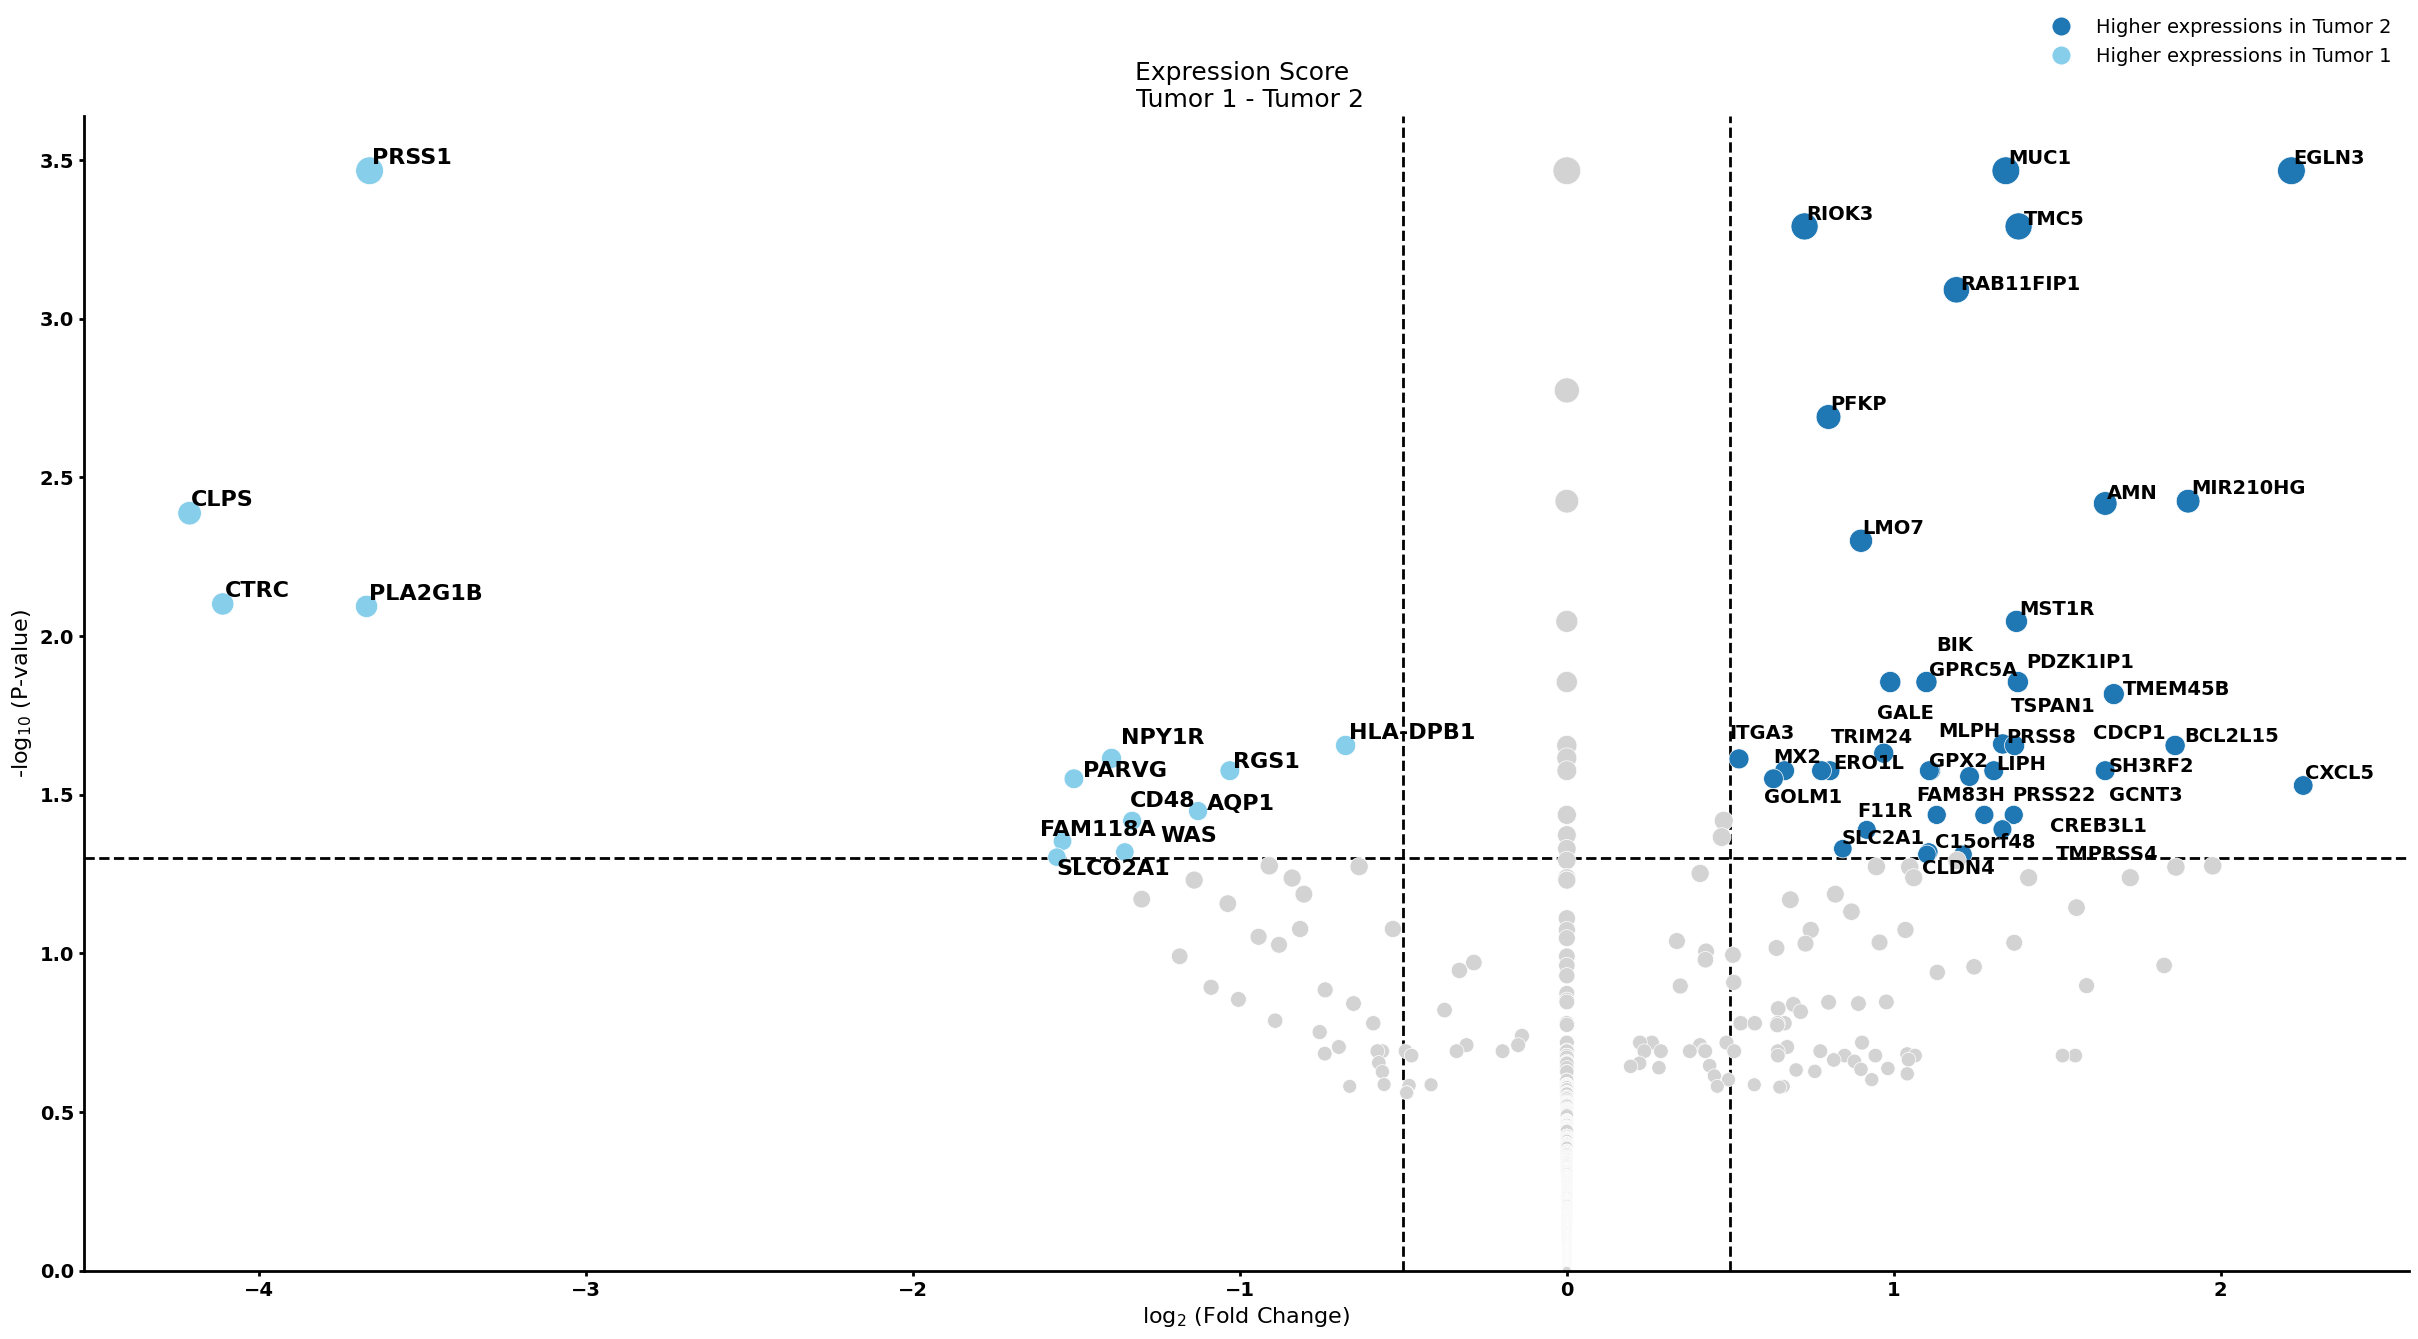

Plot GO analysis for Tumor 2 vs Tumor 1


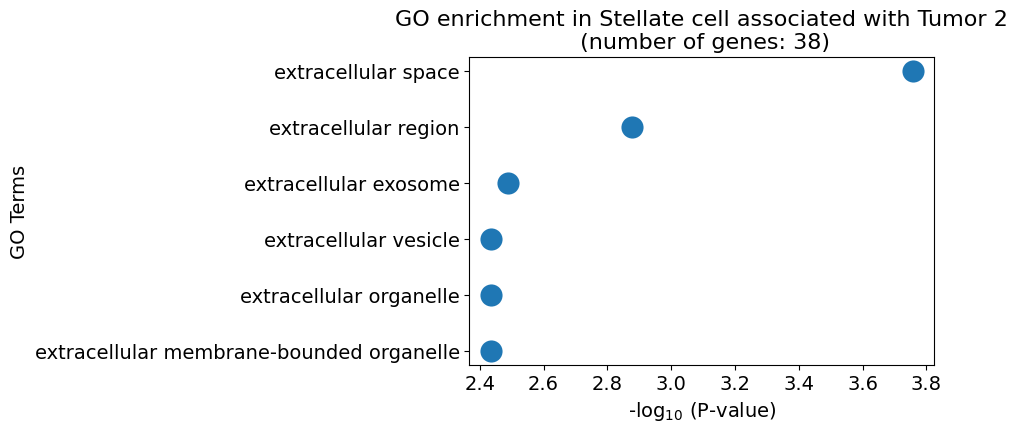

In [15]:
pl.pl.get_pseudobulk_DE(adata, proportion_df, cell_type = 'Stellate cell', fc_thr = [3.0, 4.0, 0.5])

Plot cells frequency for each sample... 


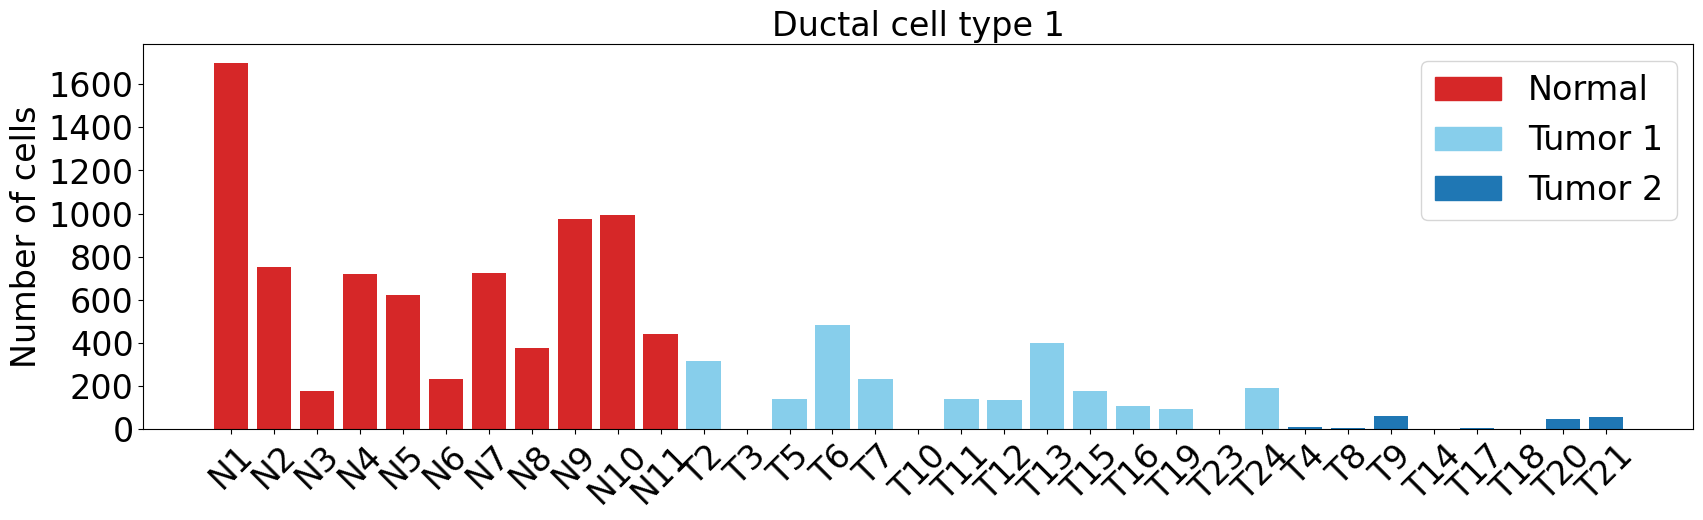

Plot the first two principal components... 


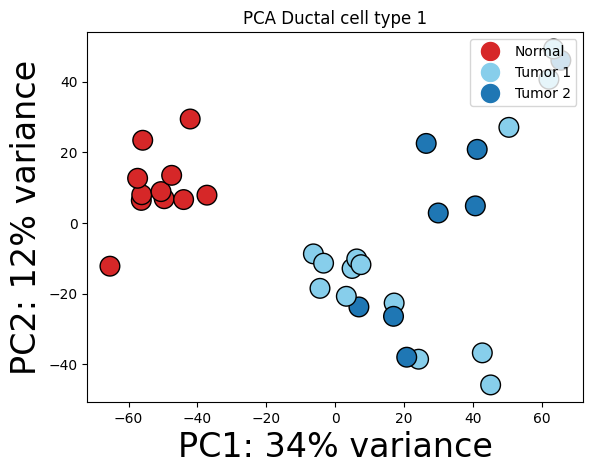

Performing the DE analysis... 
Plot volcano plot for Tumor 1 vs Normal


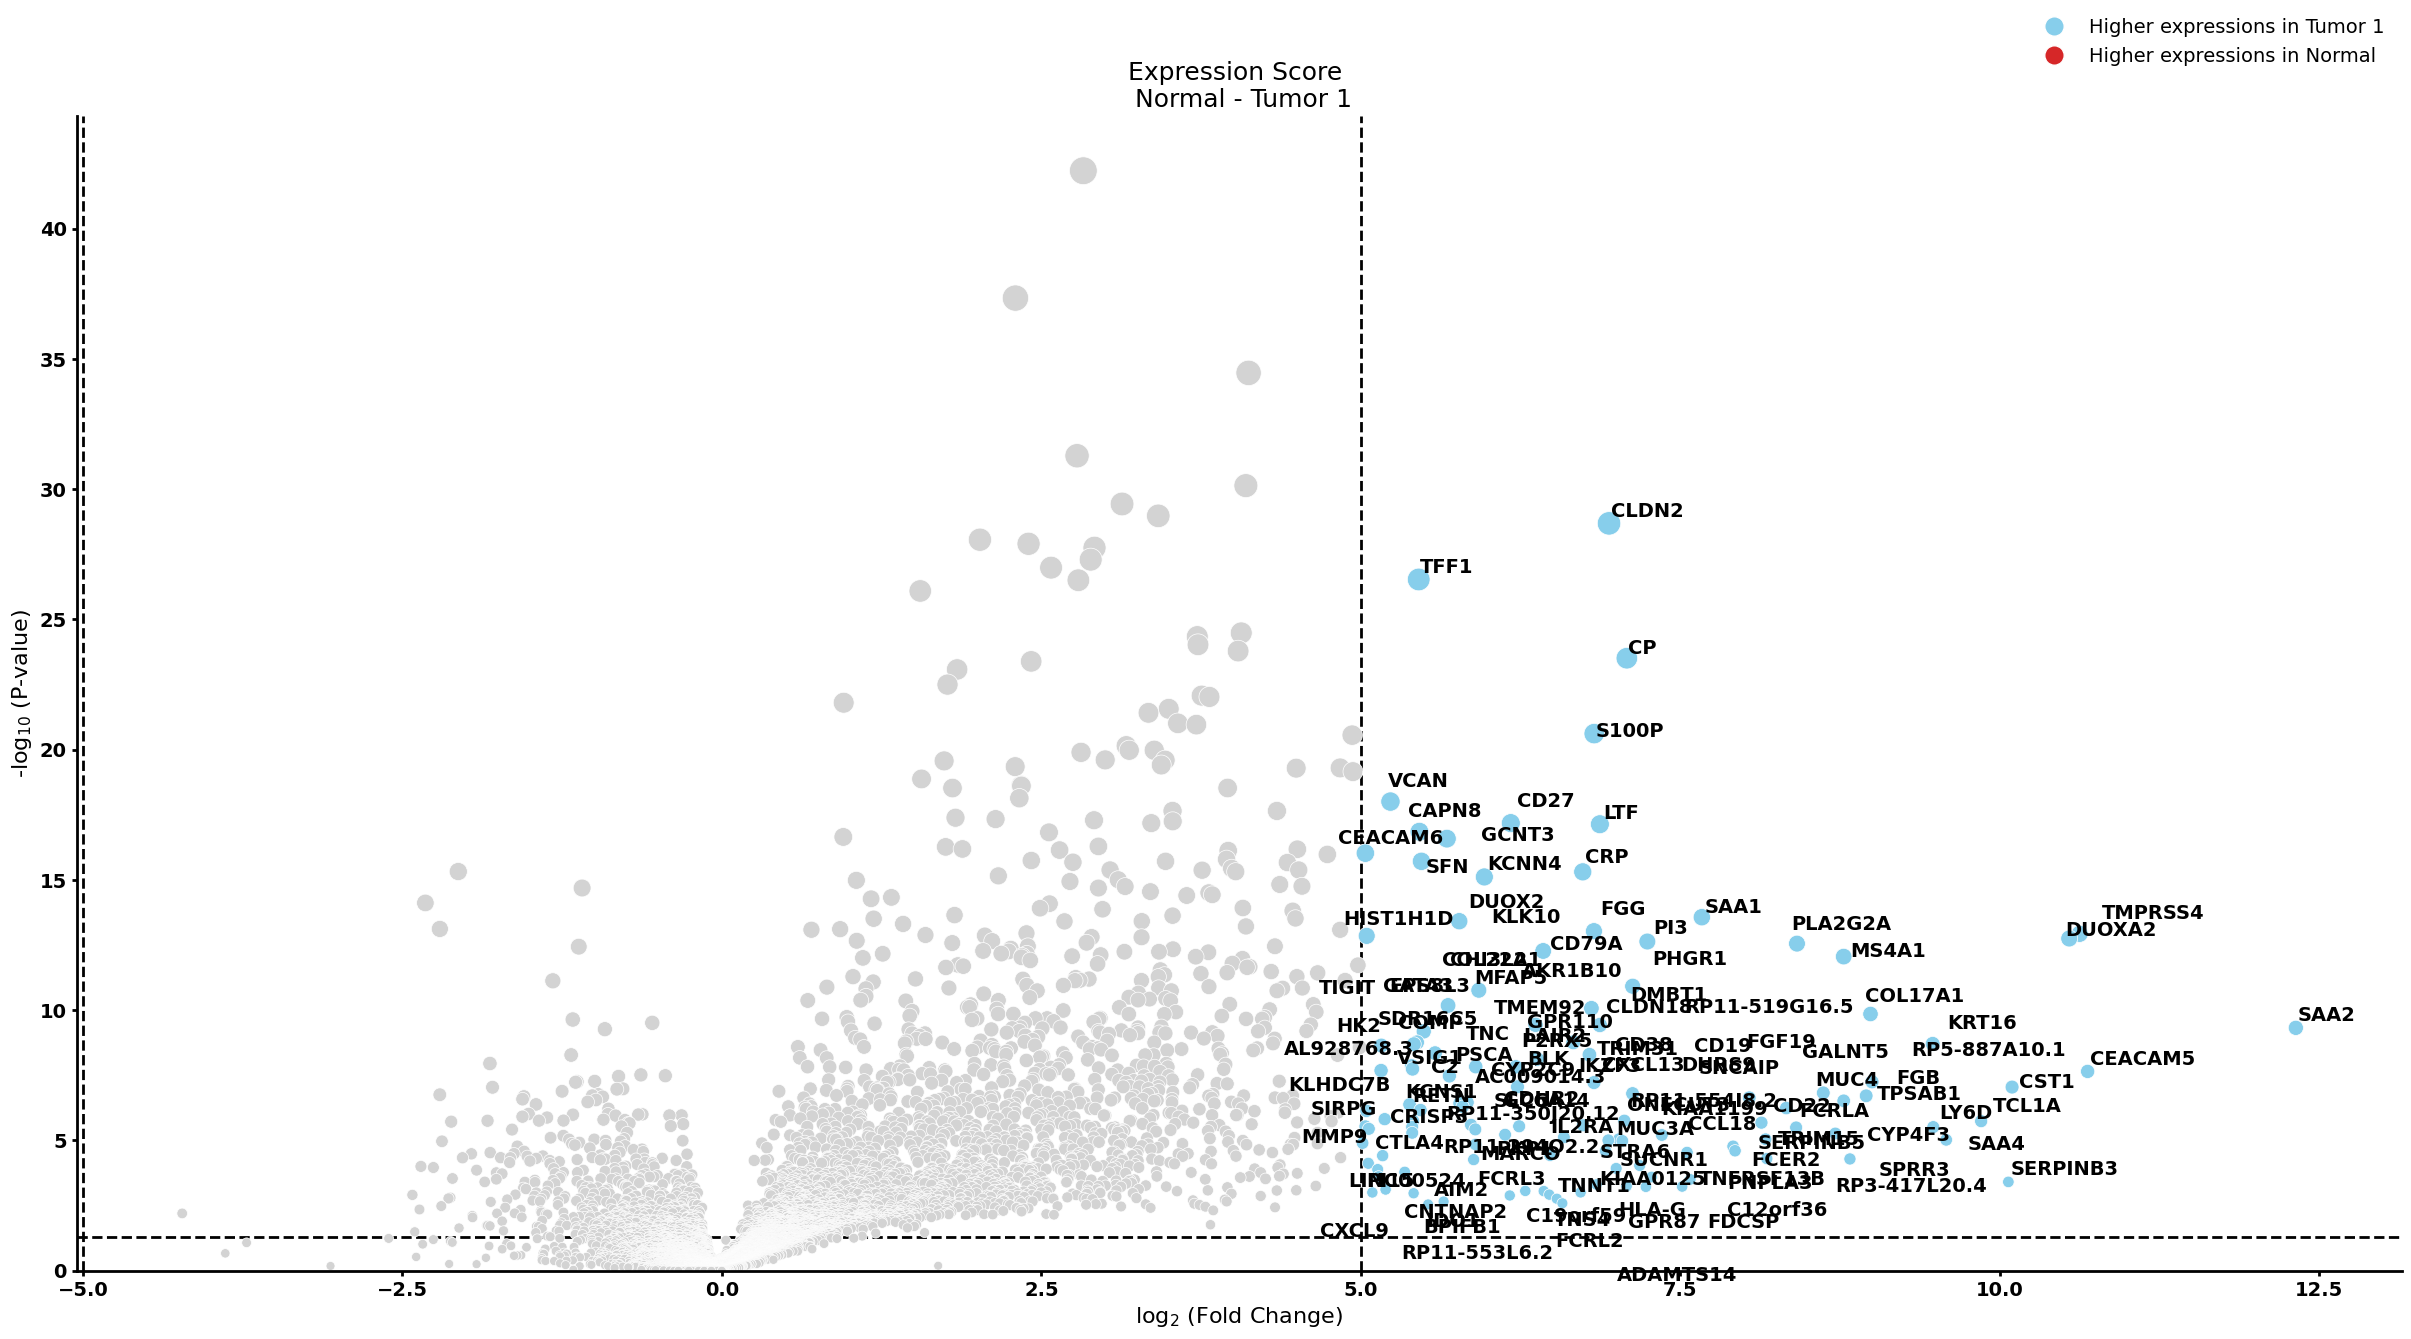

Plot GO analysis for Tumor 1 vs Normal


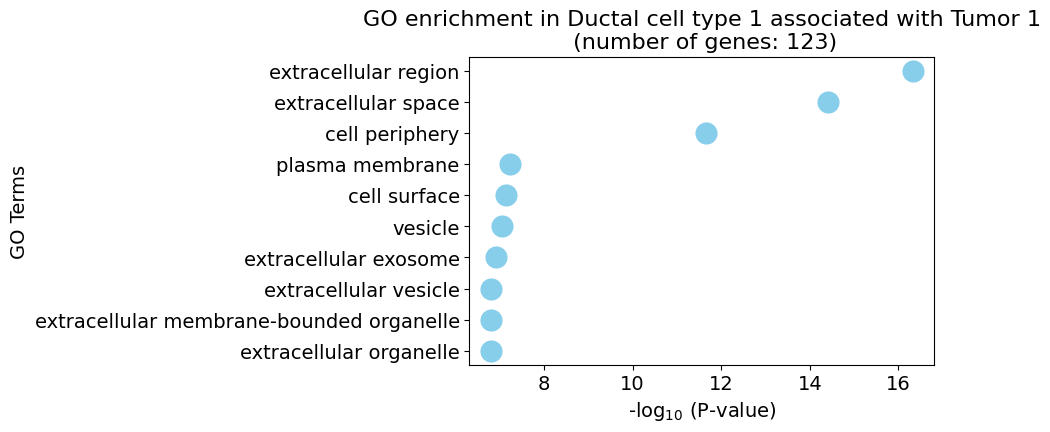

Plot volcano plot for Tumor 2 vs Normal


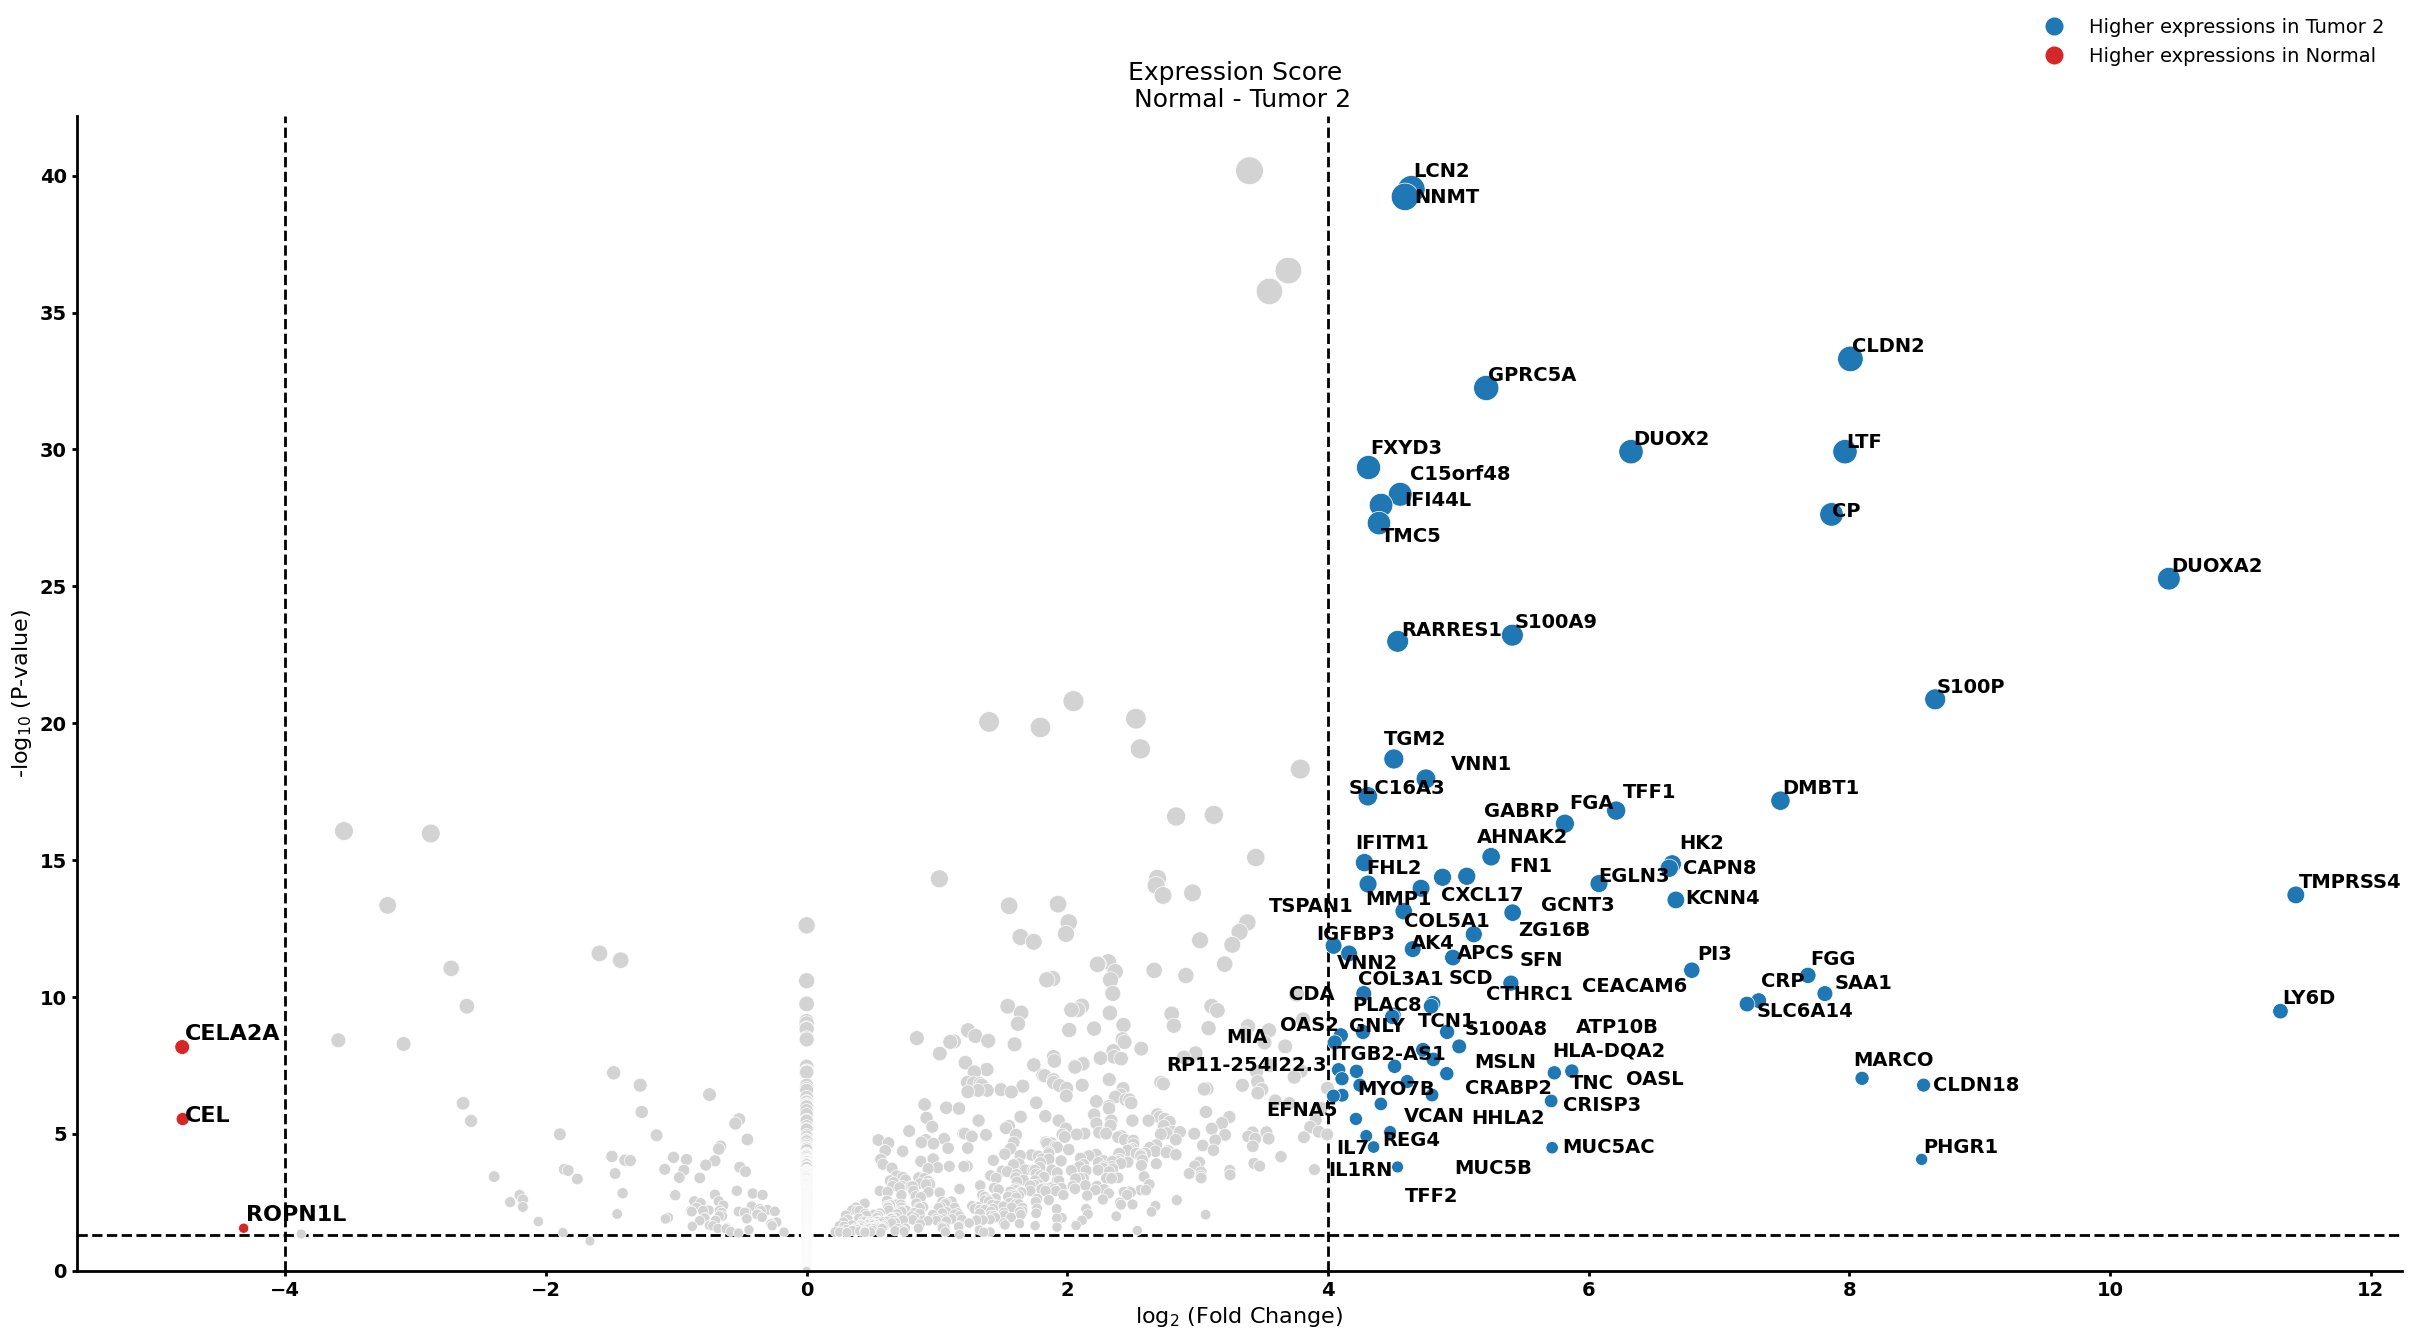

Plot GO analysis for Tumor 2 vs Normal


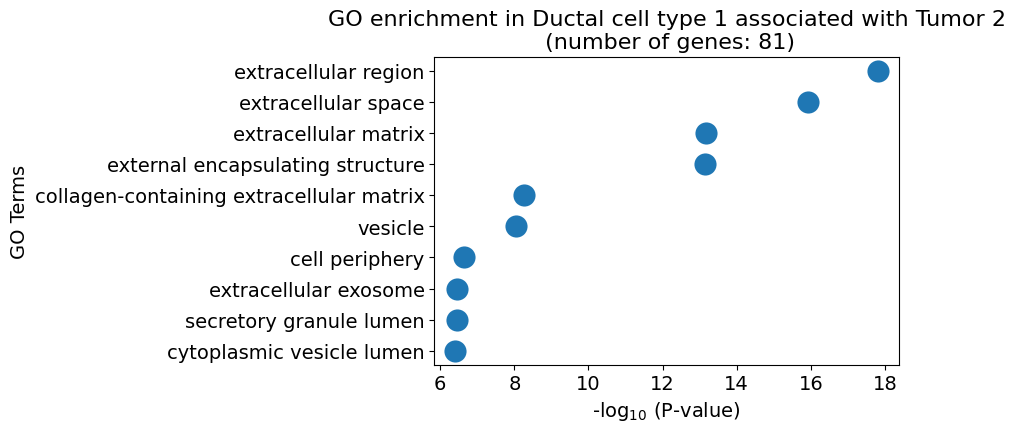

Plot volcano plot for Tumor 2 vs Tumor 1


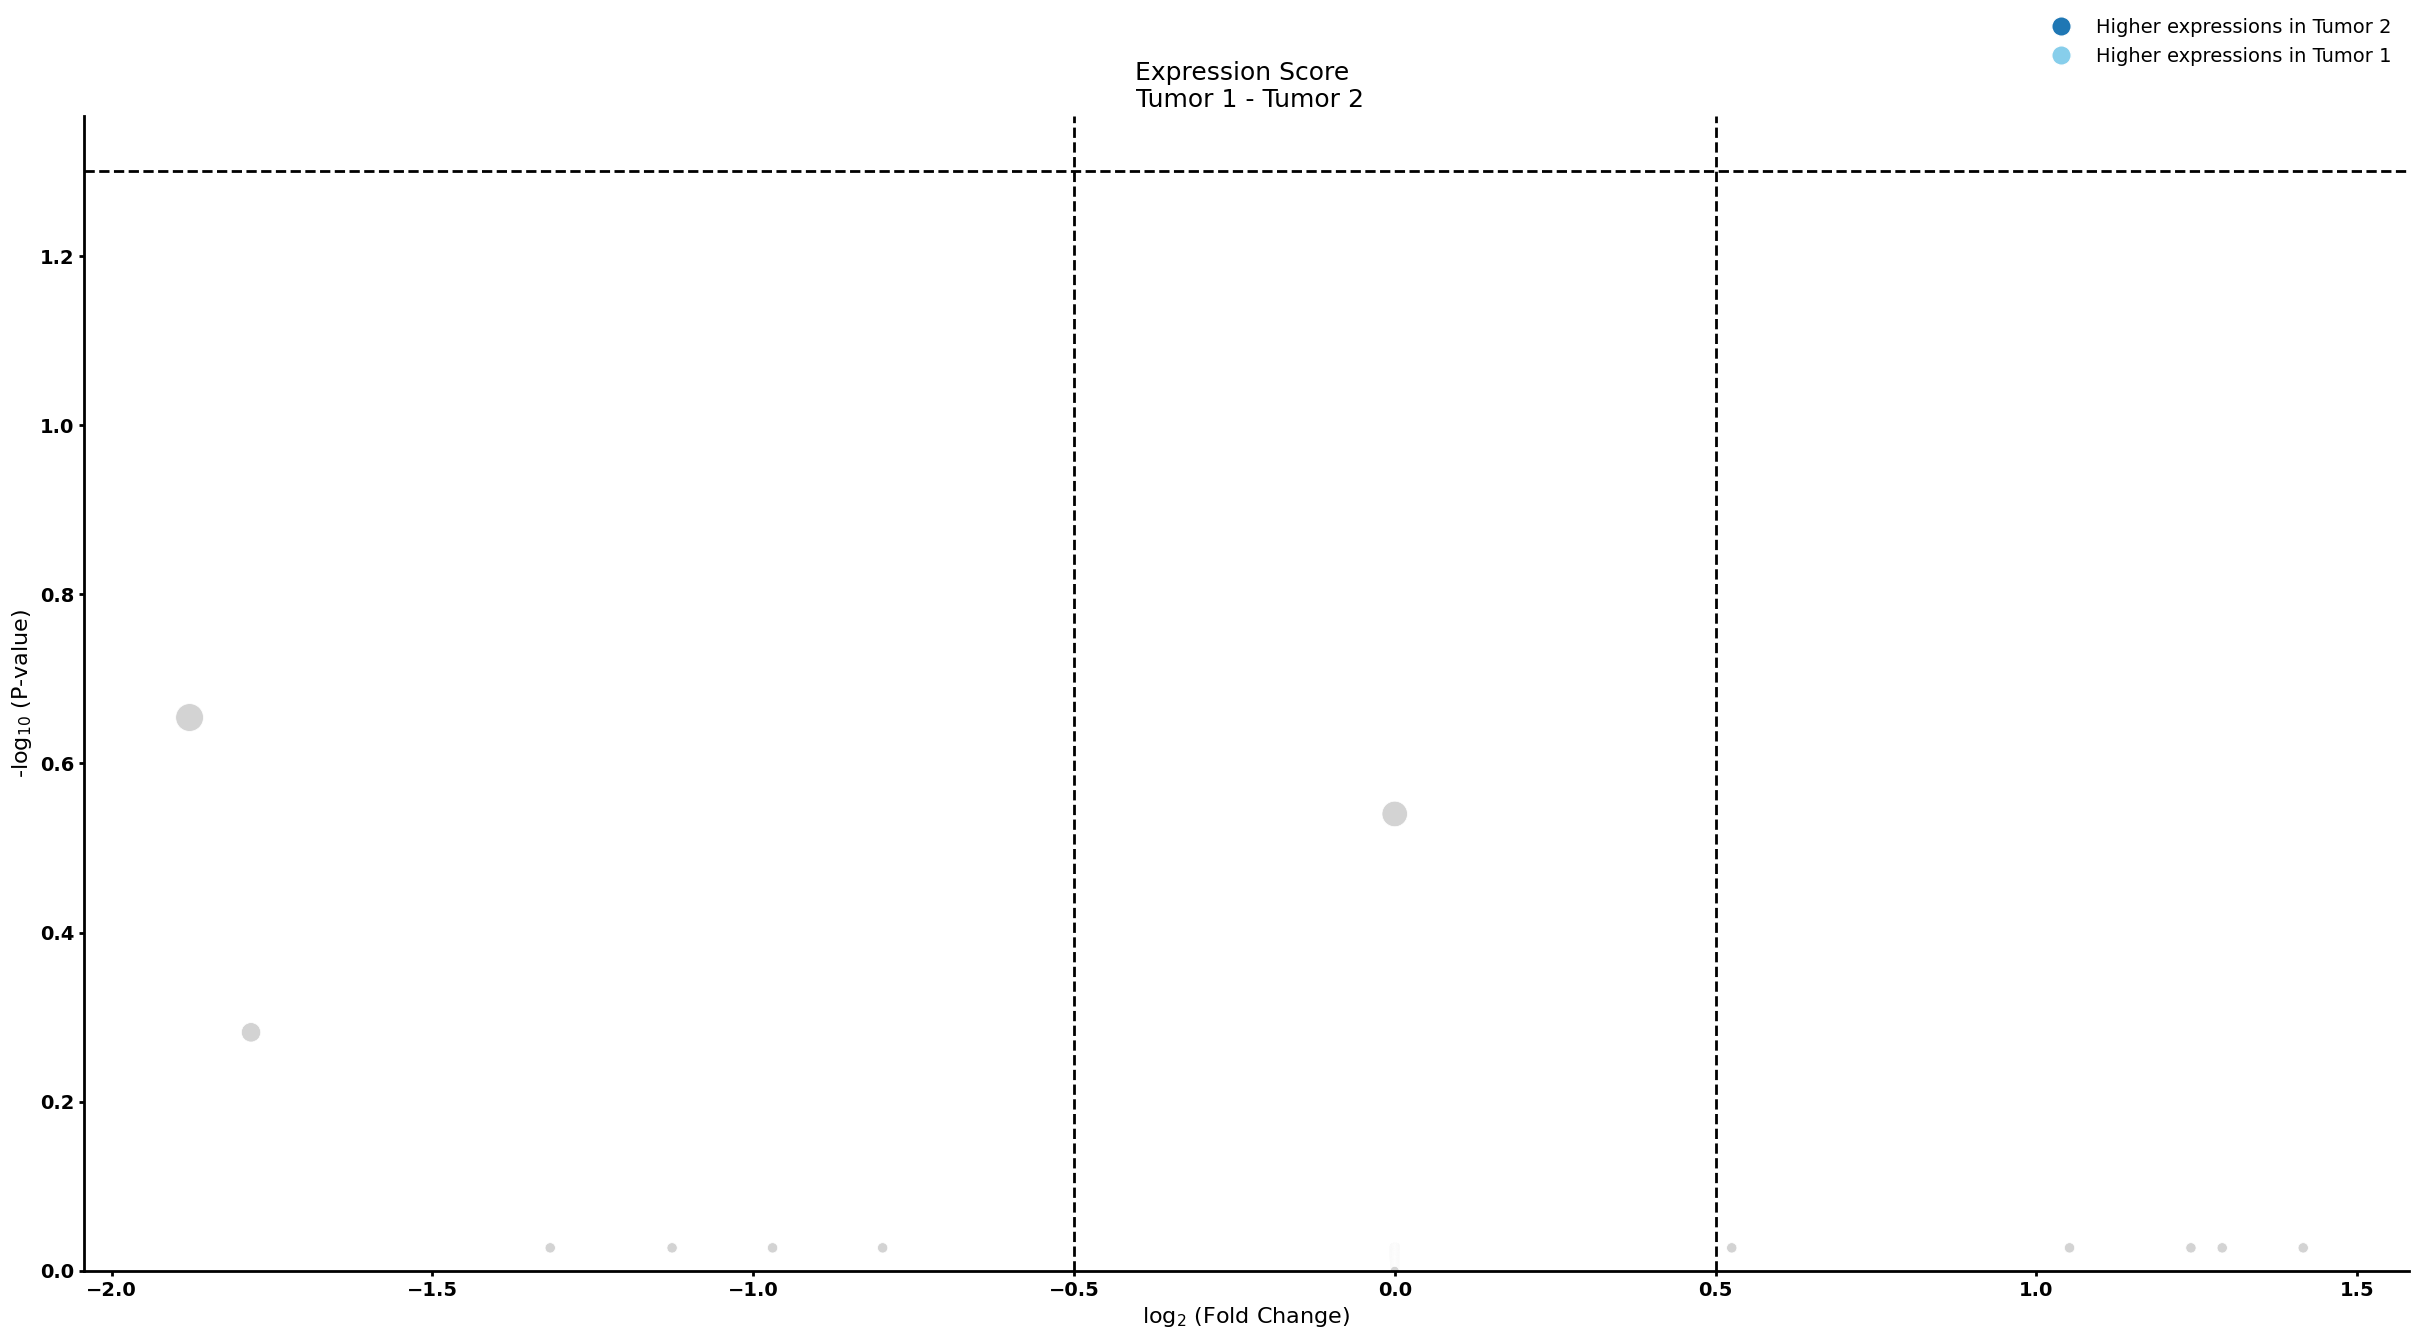

Plot GO analysis for Tumor 2 vs Tumor 1


In [12]:
pl.pl.get_pseudobulk_DE(adata, proportion_df, cell_type = 'Ductal cell type 1', fc_thr = [5.0, 4.0, 0.5])

Plot cells frequency for each sample... 


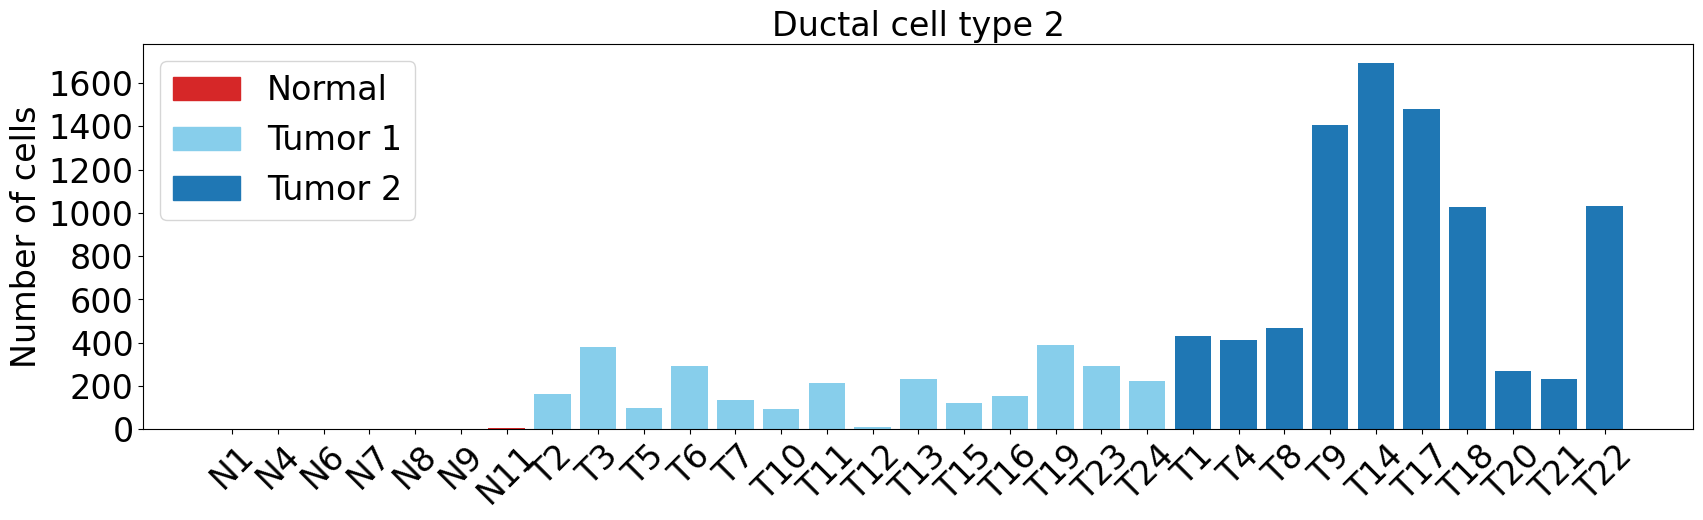

Plot the first two principal components... 


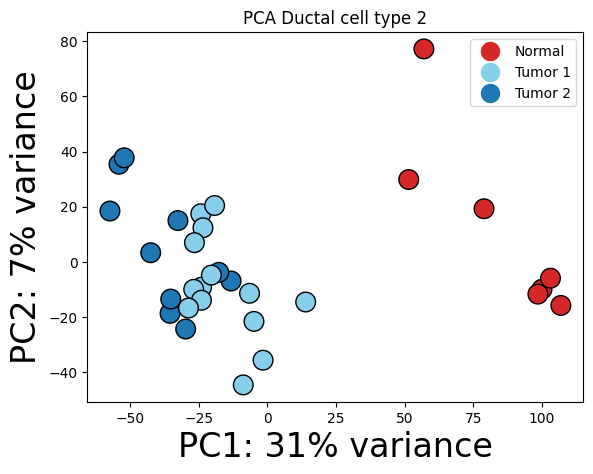

Performing the DE analysis... 
Plot volcano plot for Tumor 1 vs Normal


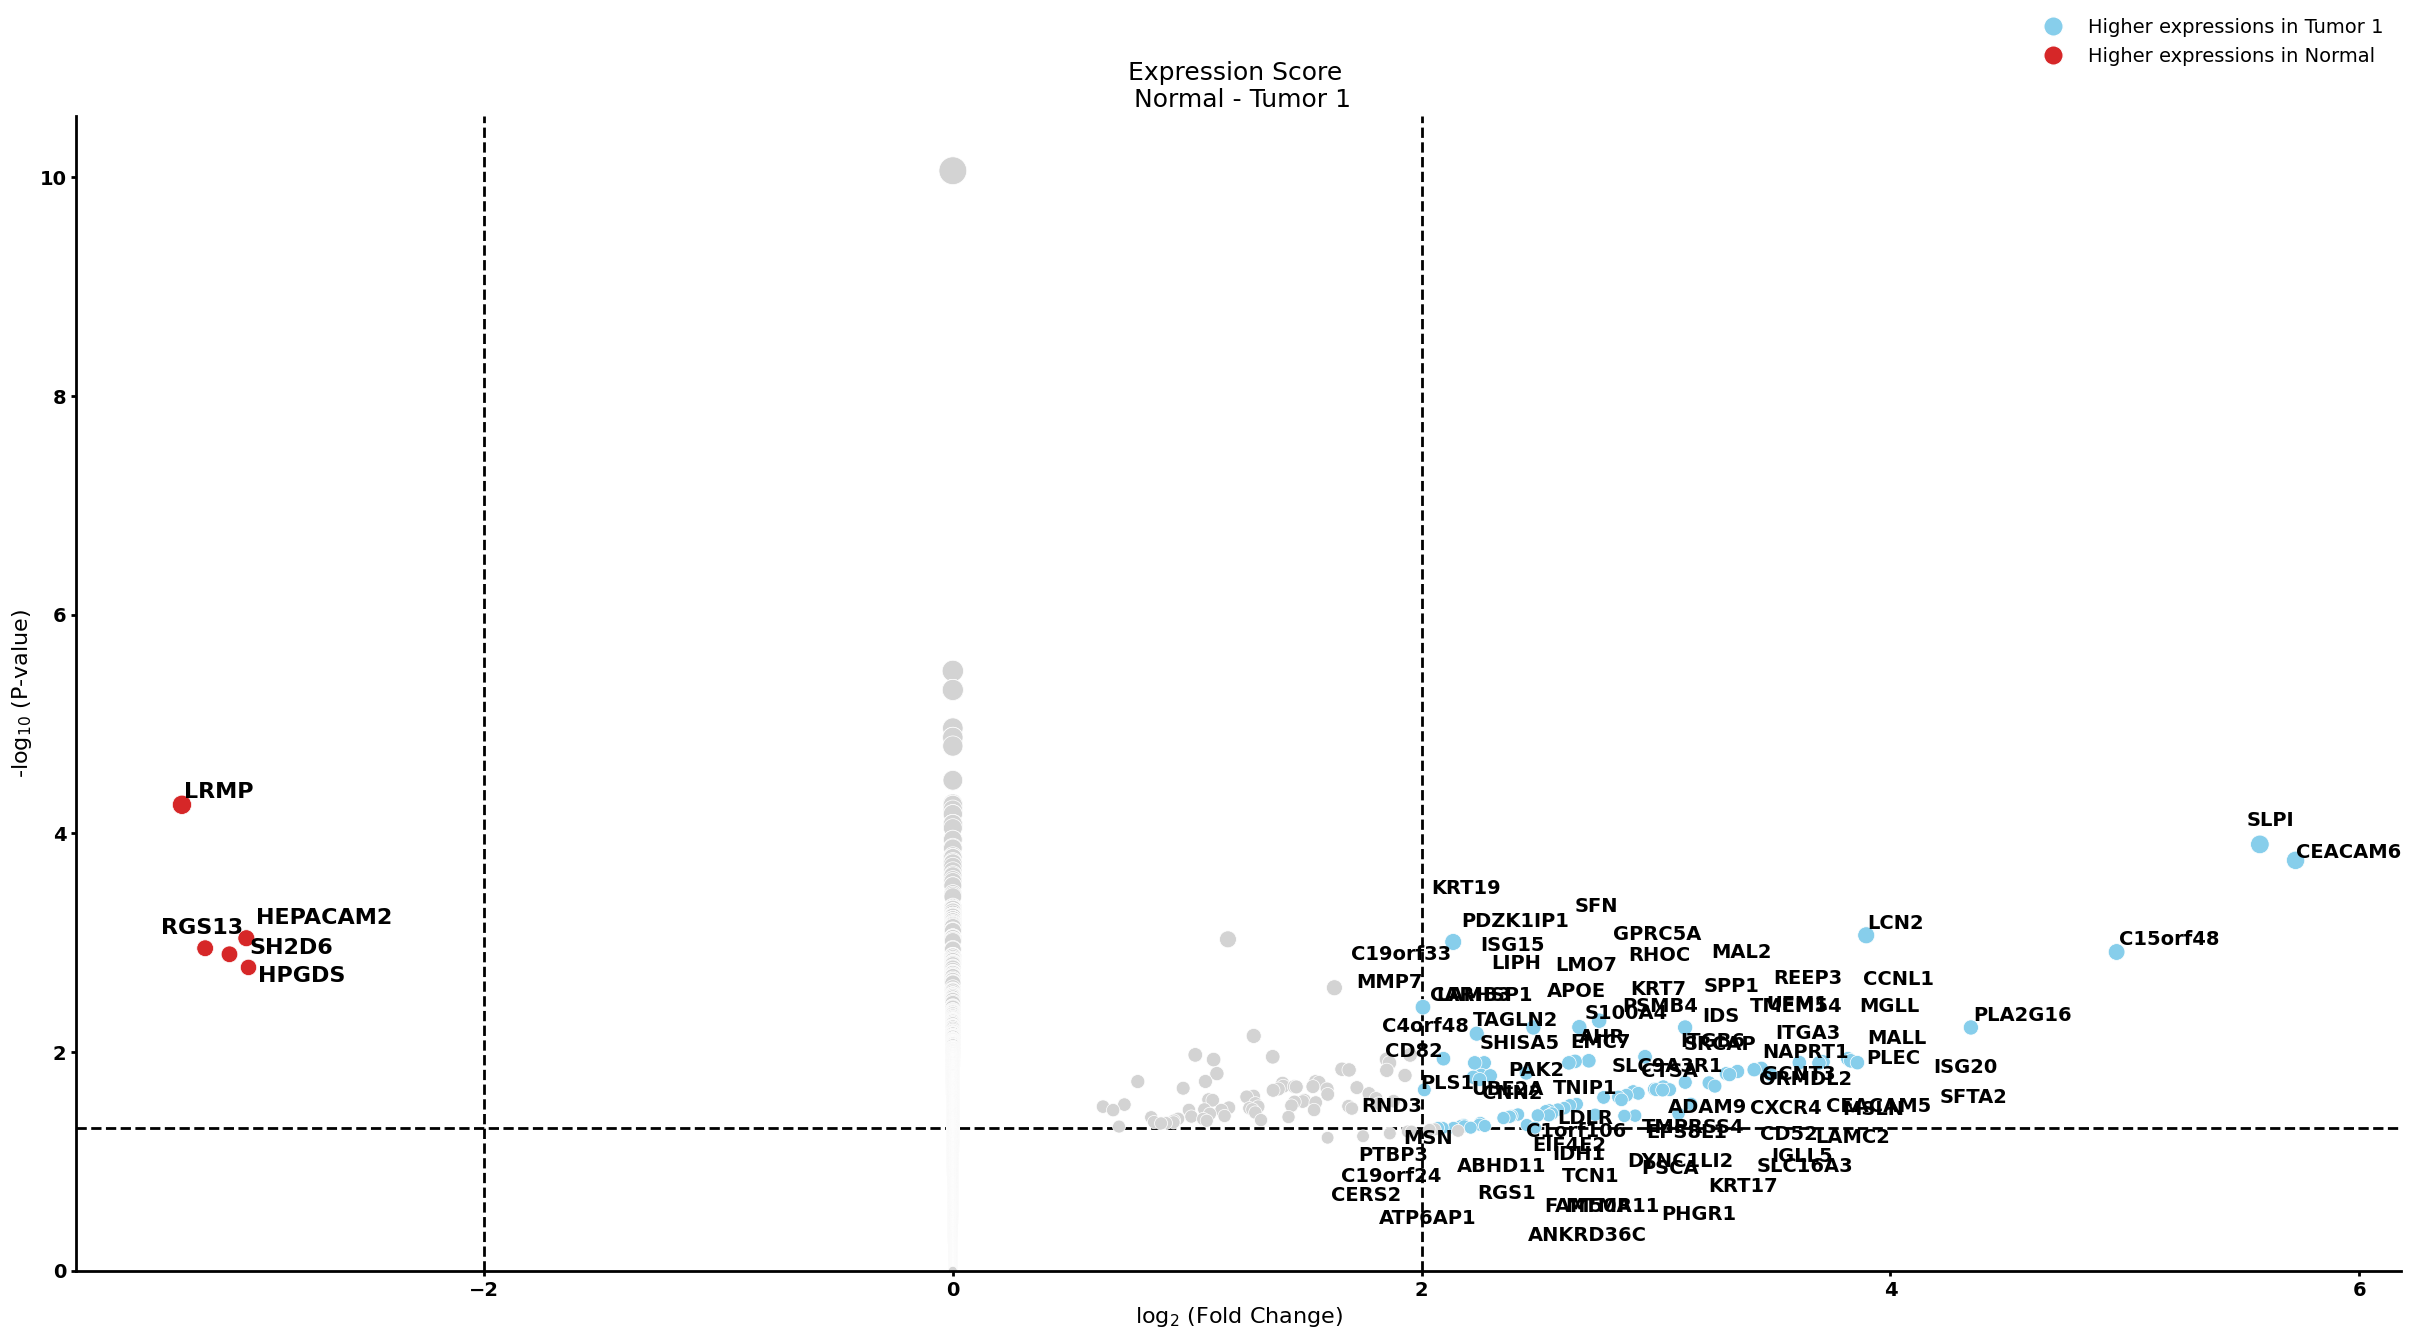

Plot GO analysis for Tumor 1 vs Normal


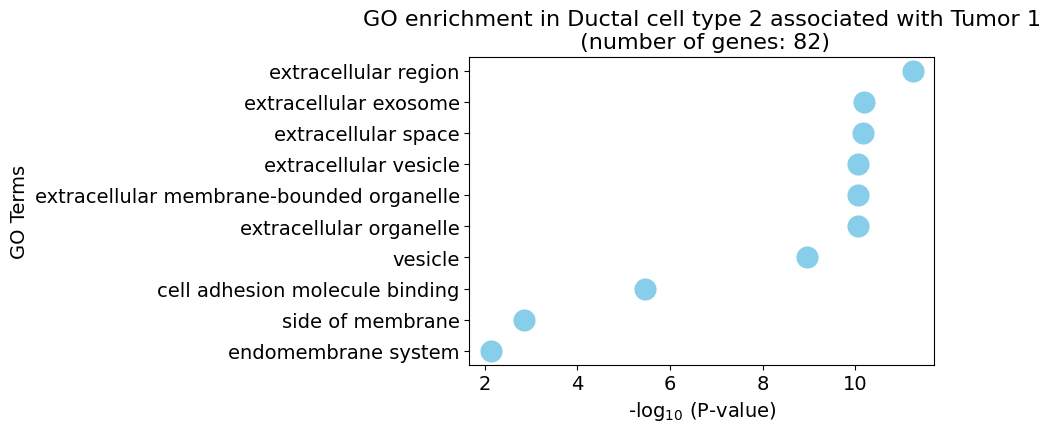

Plot volcano plot for Tumor 2 vs Normal


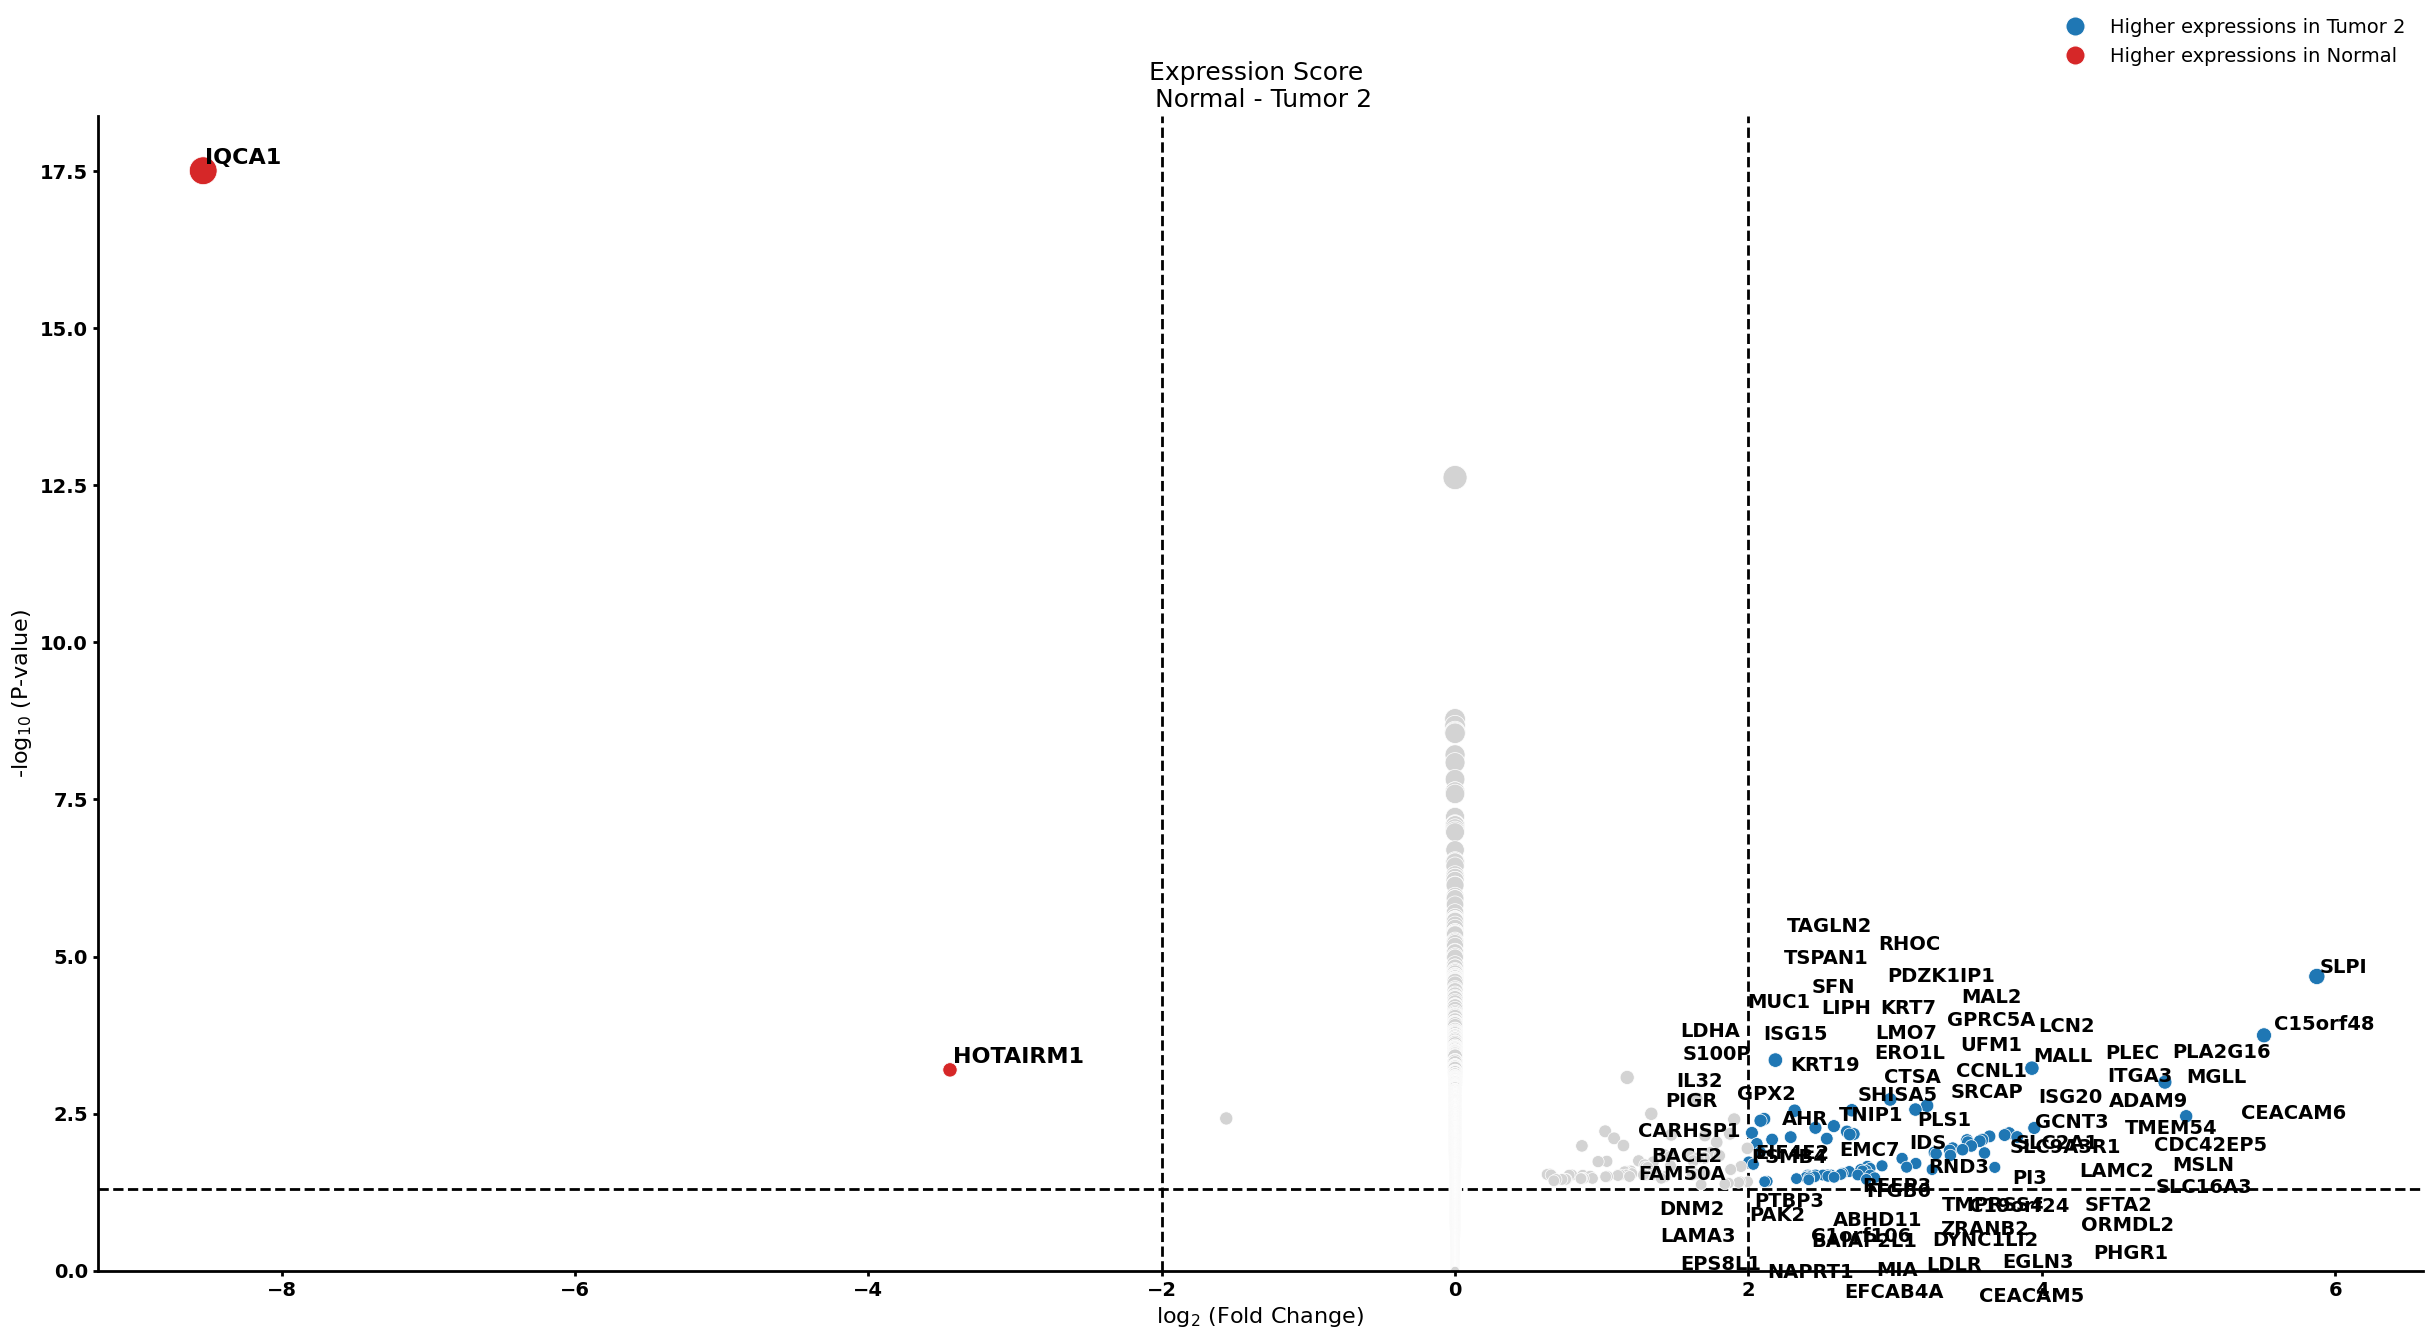

Plot GO analysis for Tumor 2 vs Normal


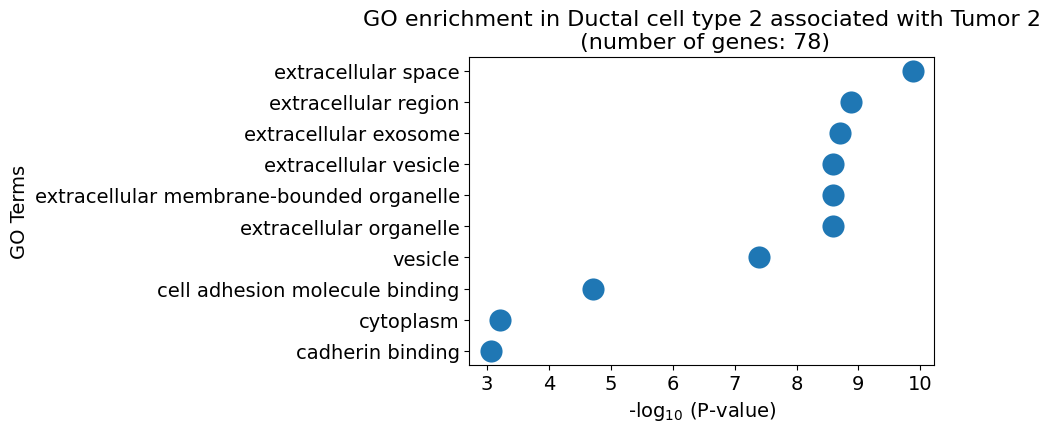

Plot volcano plot for Tumor 2 vs Tumor 1


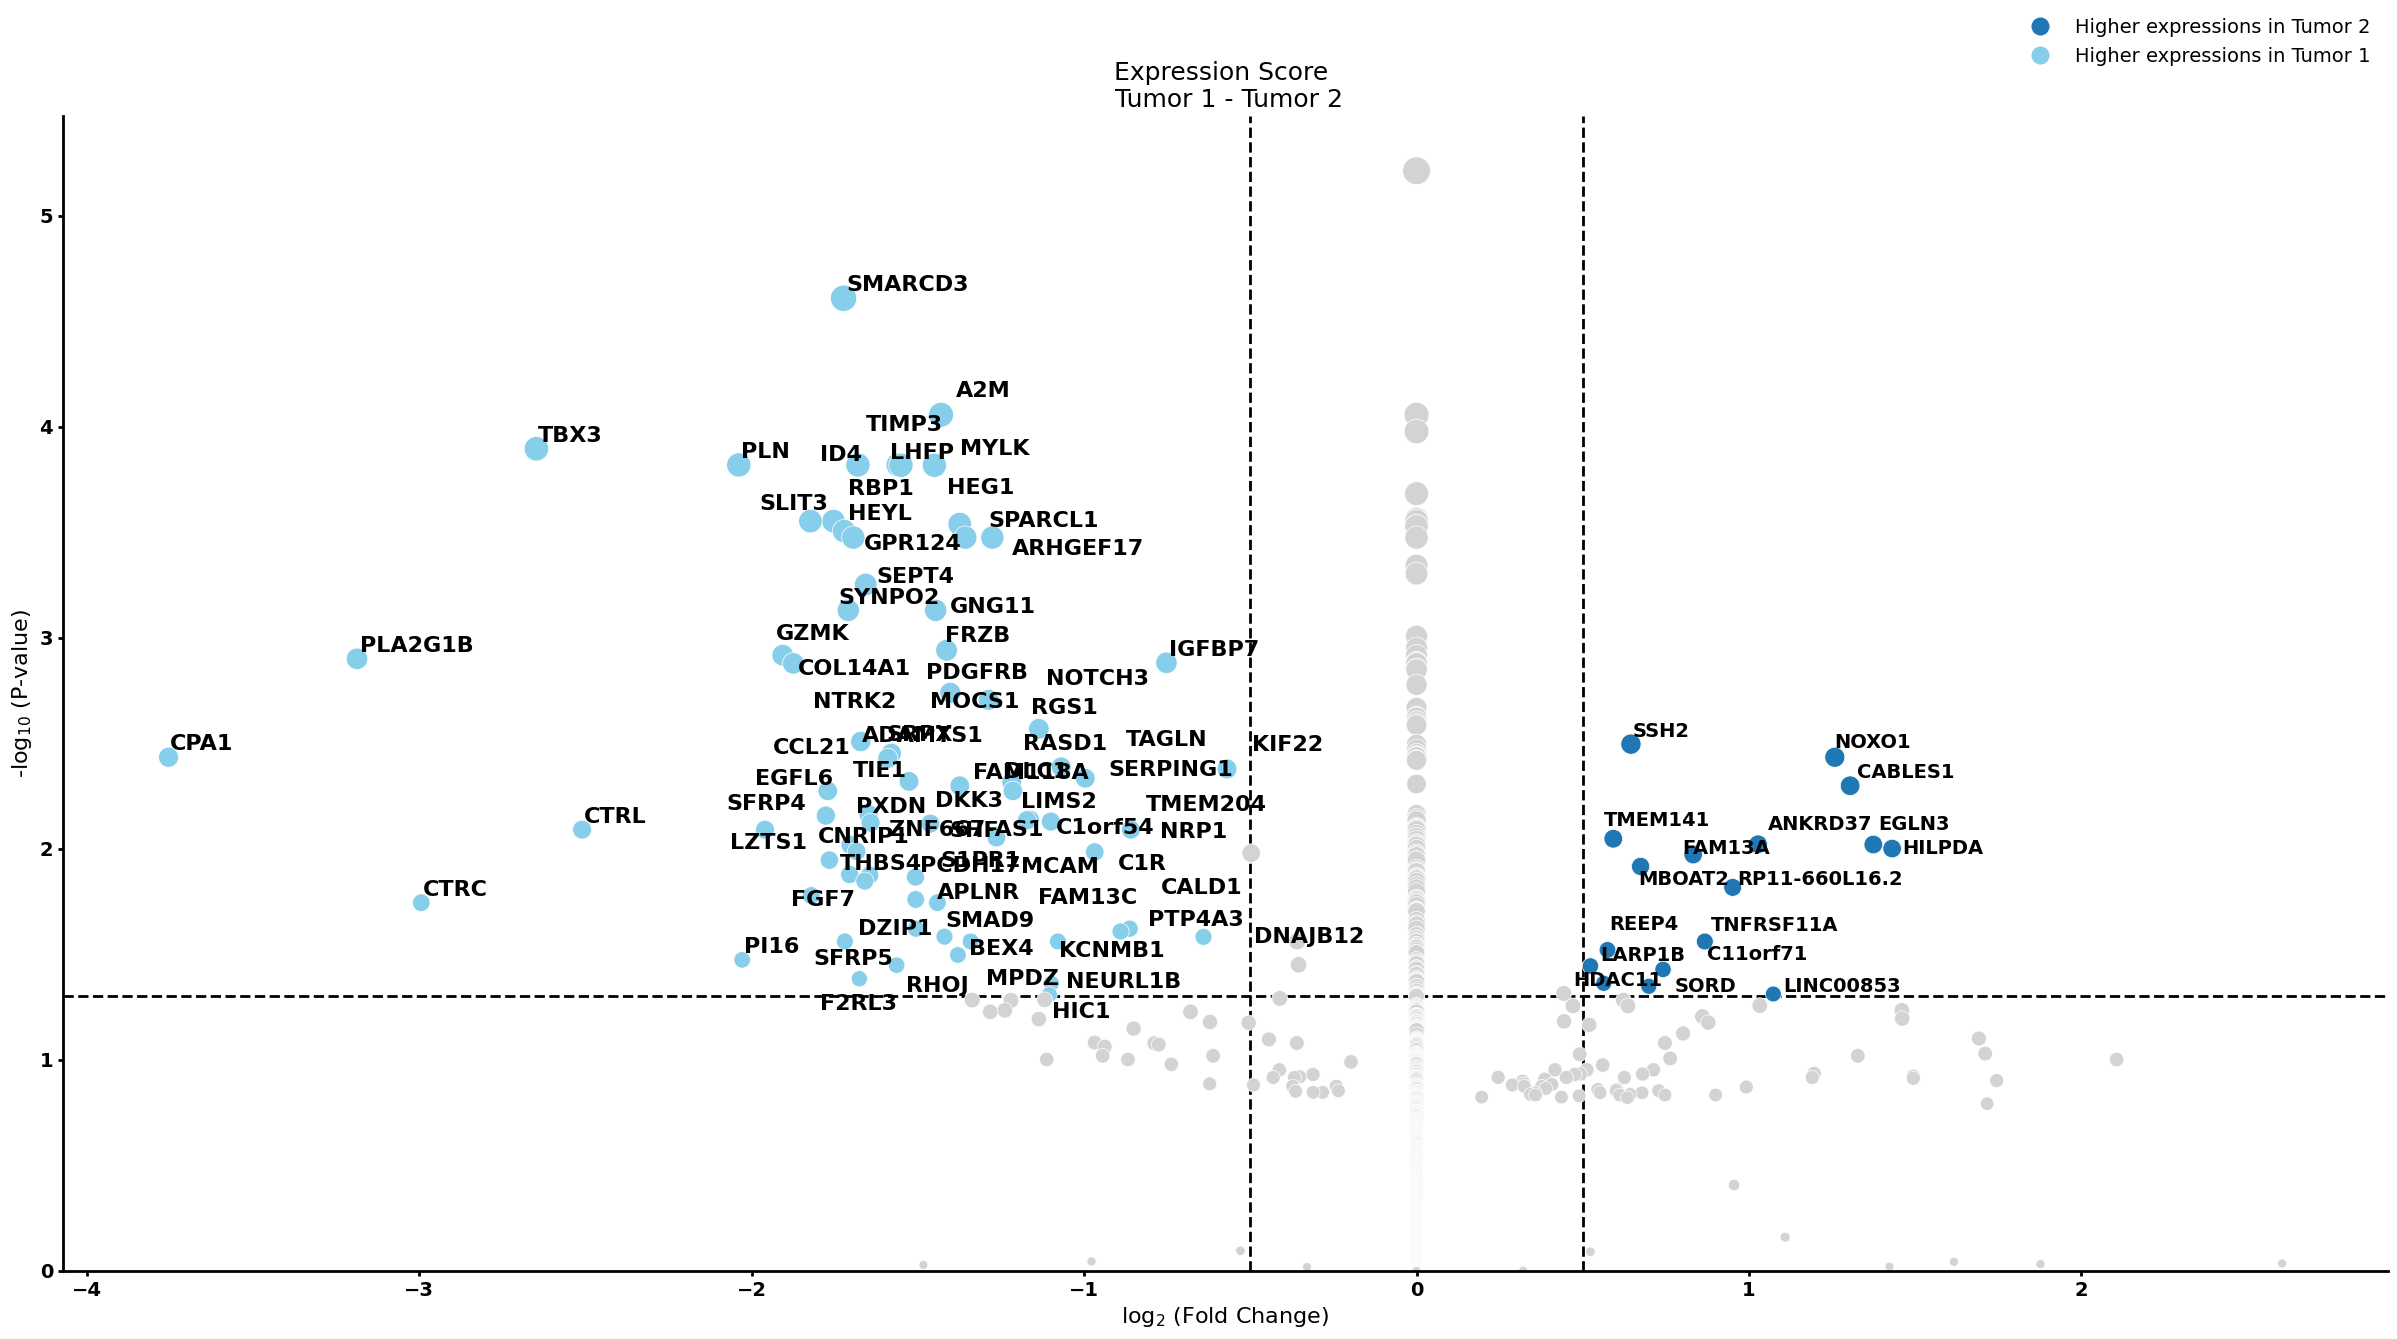

Plot GO analysis for Tumor 2 vs Tumor 1


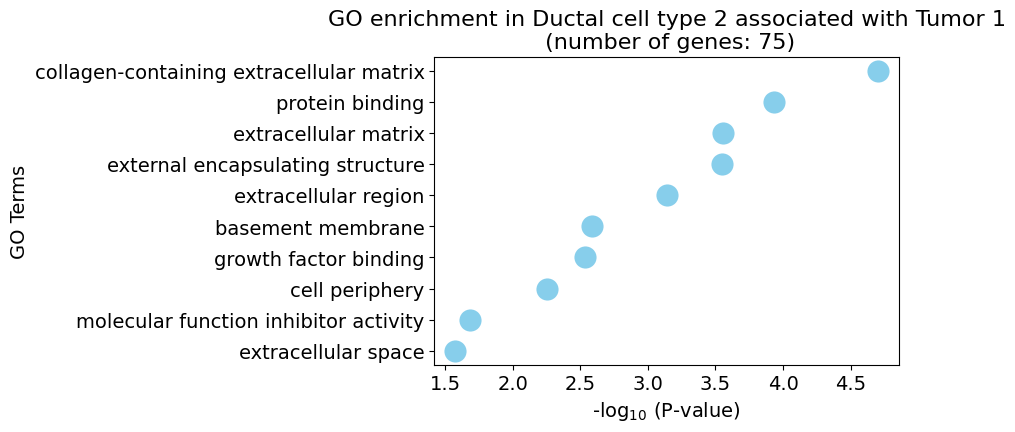

In [13]:
pl.pl.get_pseudobulk_DE(adata, proportion_df, cell_type = 'Ductal cell type 2', fc_thr = [2.0, 2.0, 0.5])